# Testing AirGravQC - Example Data

Mark Dransfield

In [1]:
import datetime
print(datetime.datetime.now())

2023-10-17 18:01:12.728584


## Introduction

## Import and Summarise

#### Import required modules, and set filenames for data and plan.

> First import external packages. *Some of these are probably not needed here.*

In [2]:
import sys
import importlib as im

# %matplotlib widget

from pathlib import Path

> Set the paths for the `AirGravQC` software and import. (One day this will require fewer steps.)

In [5]:
# Choose `local_docs` to suit you.
# local_docs = "/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/"
# local_docs = "/Users/markdransfield/"
local_docs = "/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/"
src_path = local_docs + "Documents/GitHub/AirGravQC/AirGravQC"
sys.path.insert(0, src_path)

import pointfiles as mhd
import qualityAnalysis as qc
import whizzPlot as wp
import gridfiles as grd

> Set the paths for the data. Usually the data would be from only one project but here we are including a variety of exemplars.

> Modify to suit your data.

In [8]:
data_root = local_docs + "Documents/GitHub/AirGravQC/examples/Airmag_GDF/"

muppetGDF_file = Path(data_root + r'Example_AeroMag_MuppetTown_2009.dat')
muppetHDF_file = muppetGDF_file.with_suffix('.hdf5')

### Muppet Project Measured Data

#### Convert measured XYZ data to geoWhizz, and set metadata

> The next step is essential. We need the data in HDF5 geoWhizz format because all the QC functions expect that format. (More on the geoWhizz format in the `AirGravQC` documentation.)

> Geosoft XYZ files generally have only the channel names, and no other metadata. We need the attributes of the data at project level, at line number level, and at data channel level.

In [9]:
mhd.asegToHDF(muppetGDF_file)

/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/AirGravQC/examples/Airmag_GDF/Example_AeroMag_MuppetTown_2009.dat
/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/AirGravQC/examples/Airmag_GDF/Example_AeroMag_MuppetTown_2009.dat
 Indices - line 1, flight 2, date 3, zone -1
channels out: 
['BGS_JOB', 'LINE', 'FLIGHT', 'DATE', 'FIDUCIAL', 'EAST_MGA', 'GDA94LAT', 'GDA94LON', 'MAGUNCMP', 'MAGCOMP', 'DIURNAL', 'IGRF', 'MAG_LEV', 'RAD_ALT', 'GPS_HT', 'DEM']

Getting line numbers and lengths ...
... done. Ready to create HDF file and transfer data into it.


Transferring data ...


> Now we demonstrate the use of `updateProject()` to add additional project attributes.

> It also shows the use of `updateCoordFrame()` which keeps track of the coordinate definition and the names of the channels that contain position and time. Many QC routines use position and time, so it saves effort later to have this information in the geoWhizz group attributes.

> Field data are commonly delivered to WGS84, projected to UTM, because that is what GNSS delivers. Transformation to the desired datum happens at the end of the project for the final data.

In [10]:
block_name = 'A line from Muppet Aeromag Data'
mhd.updateProject(muppetHDF_file, acquirer='Xcalibur Multiphysics', blockID=block_name)
mhd.updateCoordFrame(muppetHDF_file, lat='LATITUDE', lon='LONGITUDE', x='EASTING', y='NORTHING', time='Time_1980', alt='HEIGHT')
mhd.updateCoordFrame(muppetHDF_file, geoDatum='WGS84', htDatum='WGS84', projection='UTM', utmz='54')

Setting BlockID = Prelim Canobie Data for Canobie.hdf5.
Setting Acquirer = Xcalibur Multiphysics for Canobie.hdf5.
Changed CoordFrame attribute(s) for Canobie.hdf5.
Changed CoordFrame attribute(s) for Canobie.hdf5.


> The line attributes represent a challenge. Line numbers are usually coded to contain a number of impoprtant attributes: whether the line is a traverse, control, repeat or test line; which segment of a number of segments needed to complete the line, and whether it is a re-flight; and what is the line number of the corresponding planned line number. Each supplier uses a different coding system, and sometimes they will use different codings for different projects (or, worst of all (but vary rare), between staff processing the data on the same project!).

> AirGravQC knows only 3 of these systems so far and this will need expanding. So beware!

In [11]:
mhd.updateLineAttributes(canobieHDF_file, line_type='Xcal_can')


Setting Line attributes for Canobie.hdf5 according to the Xcal_can scheme.


> The acquirers of the data supplied a separate text file `Channel Descriptions.txt` with the requisite channel attributes metadata which then had to be entered manually via this series of commands to store it in the geoWhizz file created by `xyzToHDF()`. There is some drudgery involved here which you will have to do for your project.

> I did not enter in the supplied descriptions for the channel attributes so all that is happening here is storing the units for each channel. Units are used in some QC checking. *Could we automate this process by reading channel description files?*

In [12]:
mhd.updateChannelAttributes(canobieHDF_file, 'ANE_TC_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'AUV_TC_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'Bearing', units='degrees')
mhd.updateChannelAttributes(canobieHDF_file, 'BNE_TC_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'BUV_TC_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'CLEARANCE', units='metre')
mhd.updateChannelAttributes(canobieHDF_file, 'Date')
mhd.updateChannelAttributes(canobieHDF_file, 'DTM', units='metre')
mhd.updateChannelAttributes(canobieHDF_file, 'EASTING', units='metre')
mhd.updateChannelAttributes(canobieHDF_file, 'FIDUCIAL')
mhd.updateChannelAttributes(canobieHDF_file, 'FLIGHT')
mhd.updateChannelAttributes(canobieHDF_file, 'gD_Fourier_2p67', units='µm/s/s')
mhd.updateChannelAttributes(canobieHDF_file, 'GDD_Fourier_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'GNE_Fourier_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'GUV_Fourier_2p67', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'HDOP')
mhd.updateChannelAttributes(canobieHDF_file, 'HEIGHT', units='metre')
mhd.updateChannelAttributes(canobieHDF_file, 'JOB_ID')
mhd.updateChannelAttributes(canobieHDF_file, 'LATITUDE', units='degree')
mhd.updateChannelAttributes(canobieHDF_file, 'LINE')
mhd.updateChannelAttributes(canobieHDF_file, 'LONGITUDE', units='degree')
mhd.updateChannelAttributes(canobieHDF_file, 'Noise_NE', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'Noise_UV', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'NORTHING', units='metre')
mhd.updateChannelAttributes(canobieHDF_file, 'NumSats')
mhd.updateChannelAttributes(canobieHDF_file, 'PDOP')
mhd.updateChannelAttributes(canobieHDF_file, 'T_DD', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'T_NE', units='eotvos')
mhd.updateChannelAttributes(canobieHDF_file, 'T_UV', units='µm/s/s')
mhd.updateChannelAttributes(canobieHDF_file, 'Time_1980', units='seconds')
mhd.updateChannelAttributes(canobieHDF_file, 'Time_Day', units='seconds')
mhd.updateChannelAttributes(canobieHDF_file, 'TURBULENCE', units='m/s/s')
mhd.updateChannelAttributes(canobieHDF_file, 'VDOP')

Changed channel attribute(s) for ANE_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for AUV_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for Bearing in Canobie.hdf5.
Changed channel attribute(s) for BNE_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for BUV_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for CLEARANCE in Canobie.hdf5.
Changed channel attribute(s) for DTM in Canobie.hdf5.
Changed channel attribute(s) for EASTING in Canobie.hdf5.
Changed channel attribute(s) for gD_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GDD_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GNE_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GUV_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for HEIGHT in Canobie.hdf5.
Changed channel attribute(s) for LATITUDE in Canobie.hdf5.
Changed channel attribute(s) for LONGITUDE in Canobie.hdf5.
Changed channel attribute(s) for Noise_NE in Canobie.hdf5.
Changed channel attr

#### Summary report of measured data

> Summary report of contents of data file. The `reportWhizz()` code can list attributes of a line via the `line=...` keyword, or a channel via the `channel=...` keyword.

In [13]:
mhd.reportWhizz(canobieHDF_file, channel='ANE_TC_2p67')

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Coordinates
    AltitudeChannel: HEIGHT
    GeoDatum: WGS84
    HeightDatum: WGS84
    LatitudeChannel: LATITUDE
    LongitudeChannel: LONGITUDE
    Projection: UTM
    TimeChannel: Time_1980
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
6 lines: total distance flown [km] = 360.0

6 lines:
 ['100010.0', '100020.0', '100030.0', '100040.0', '100050.0', '100060.0']

33 channels:
 ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing', 'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67', 'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE', 'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP', 'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67']

Channel <HDF5 dataset "ANE_TC_2p67": shape (8040,), type "<f8">
    Name: ANE_TC_2p67
    Un

In [14]:
mhd.reportFlights(canobieHDF_file, detailed=True)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

2 flights including 6 lines.

Flights
    2
      L100010.0 L100020.0 
    3
      L100030.0 L100040.0 L100050.0 L100060.0 



> Sample times should be constant. Here we have one at 0.126 which ought to be checked. Sample distances vary with aircraft ground speed.

In [15]:
mhd.reportSampling(canobieHDF_file)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Sample time and distance statistics
  Min   = 0.125 s, 6.8 m
  Max   = 0.126 s, 7.9 m
  Mean  = 0.125 s, 7.4 m
  Stdev = 3.33e-05 s, 0.2 m


### Canobie Plan Data

#### Convert plan XYZ data to geoWhizz, and set metadata

In this example, the plan data file only has the (x,y) locations of the start and end of each line and we have no planned heights. The process is the same as for the acquired survey data `XYZ` file above.

In [16]:
mhd.xyzToHDF(Path(canobieXYZ_plan), projectName='Canobie')
block_name = 'Survey Plan'
mhd.updateProject(canobieHDF_plan, acquirer='Xcalibur Multiphysics', blockID=block_name)

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/CanobiePlan.xyz.
First few records are:
   /EASTING  NORTHING  FLAG

   LINE      1


  Found 1 header records
  Found 78 lines
  Found 3 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/CanobiePlan.hdf5
Setting BlockID = Survey Plan for CanobiePlan.hdf5.
Setting Acquirer = Xcalibur Multiphysics for CanobiePlan.hdf5.


In [17]:
mhd.updateCoordFrame(canobieHDF_plan, x='EASTING', y='NORTHING')
mhd.updateCoordFrame(canobieHDF_plan, geoDatum='WGS84', projection='UTM', utmz='54')
mhd.updateLineAttributes(canobieHDF_plan, line_type='Xcal_can')

Changed CoordFrame attribute(s) for CanobiePlan.hdf5.
Changed CoordFrame attribute(s) for CanobiePlan.hdf5.

Setting Line attributes for CanobiePlan.hdf5 according to the Xcal_can scheme.


In [18]:
mhd.updateChannelAttributes(canobieHDF_plan, 'EASTING', units='m')
mhd.updateChannelAttributes(canobieHDF_plan, 'NORTHING', units='m')

Changed channel attribute(s) for EASTING in CanobiePlan.hdf5.
Changed channel attribute(s) for NORTHING in CanobiePlan.hdf5.


#### Summary report of plan data

In [19]:
mhd.reportWhizz(canobieHDF_plan)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Survey Plan
    ProjectName: Canobie

Coordinates
    GeoDatum: WGS84
    Projection: UTM
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
78 lines: total distance flown [km] = 4,985.7

78 lines:
 ['1.0', '100010.0', '100020.0', '100030.0', '100040.0', '100050.0', '100060.0', '100070.0', '100080.0', '100090.0', '100100.0', '100110.0', '100120.0', '100130.0', '100140.0', '100150.0', '100160.0', '100170.0', '100180.0', '100190.0', '100200.0', '100210.0', '100220.0', '100230.0', '100240.0', '100250.0', '100260.0', '100270.0', '100280.0', '100290.0', '100300.0', '100310.0', '100320.0', '100330.0', '100340.0', '100350.0', '100360.0', '100370.0', '100380.0', '100390.0', '100400.0', '100410.0', '100420.0', '100430.0', '100440.0', '100450.0', '100460.0', '100470.0', '100480.0', '100490.0', '100500.0', '100510.0', '100520.0', '100530.0', '100540.0', '100550.0', '100560.0', '100570.0', '100580.0', '100590.0', '100600.

#### Map showing flown lines against plan.

> This provides a visual check that the lines are in about the right location and shows the amount of the survey flown so far.

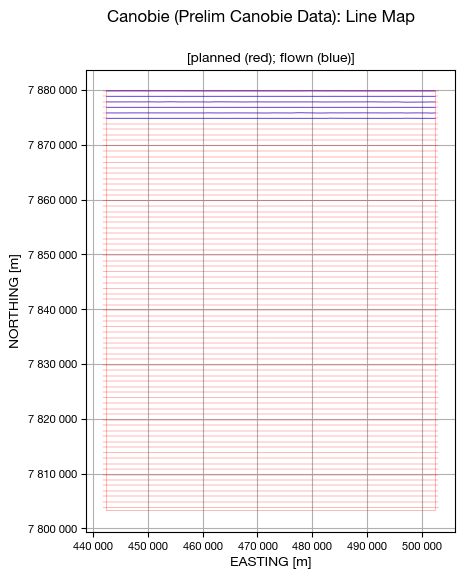

In [20]:
wp.linesMap([canobieHDF_file], whizzPlanFile=canobieHDF_plan)

### EastVic Project Measured Data

In [22]:
mhd.xyzToHDF(Path(EastVicXYZ_file), projectName='EastVic')

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVic.xyz.
First few records are:
   /    ATMCOR B100s_267_GEOID B100s_267_GRS80 B56s_267_GEOID B56s_267_GRS80    DEM        DOY     EOTCOR FA100s_GEOID FA100s_GRS80 FA56s_GEOID FA56s_GRS80 FACOR_GEOID FACOR_GRS80     FLIGHT      FTIME         FX         FY         FZ       HDOP   LALT            LAT     LATCOR       LINE           LONG      MGA_X      MGA_Y   MGA_Z   MSL_Z      NSATS       PDOP    RALT    STATCOR      TACOR     V_EAST    V_NORTH       VDOP       YEAR

   //Flight 0

   //Date 2022/07/13

   Line  2341.50


  Found 17 header records
  Found 8 lines
  Found 38 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVic.hdf5


PosixPath('/Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVic.hdf5')

In [23]:
block_name = 'EastVic Field Data'
mhd.updateProject(EastVicHDF_file, acquirer='Sander Geophysics', blockID=block_name)
mhd.updateCoordFrame(EastVicHDF_file, lat='LAT', lon='LONG', x='MGA_X', y='MGA_Y', time='FTIME', alt='MGA_Z')
mhd.updateCoordFrame(EastVicHDF_file, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='55')

Setting BlockID = EastVic Field Data for EastVic.hdf5.
Setting Acquirer = Sander Geophysics for EastVic.hdf5.
Changed CoordFrame attribute(s) for EastVic.hdf5.
Changed CoordFrame attribute(s) for EastVic.hdf5.


In [24]:
mhd.updateLineAttributes(EastVicHDF_file, line_type='SGL_GA', flight_chan='FLIGHT', date_chan="DOY")


Setting Line attributes for EastVic.hdf5 according to the SGL_GA scheme.
Setting Line attributes for EastVic.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for EastVic.hdf5 to include dates from DOY.


In [25]:
mhd.updateChannelAttributes(EastVicHDF_file, 'FTIME', units='s')
mhd.updateChannelAttributes(EastVicHDF_file, 'MGA_X', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'MGA_Y', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'MGA_Z', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'MSL_Z', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'LAT', units='degree')
mhd.updateChannelAttributes(EastVicHDF_file, 'LONG', units='degree')
mhd.updateChannelAttributes(EastVicHDF_file, 'DEM', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'RALT', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'LALT', units='m')
mhd.updateChannelAttributes(EastVicHDF_file, 'FX', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FY', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FZ', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'V_EAST', units='m/s')
mhd.updateChannelAttributes(EastVicHDF_file, 'V_NORTH', units='m/s')
mhd.updateChannelAttributes(EastVicHDF_file, 'EOTCOR', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'LATCOR', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'STATCOR', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'ATMCOR', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FACOR_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FACOR_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'TACOR', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FA56s_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FA56s_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FA100s_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'FA100s_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'B56s_267_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'B56s_267_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'B100s_267_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicHDF_file, 'B100s_267_GEOID', units='mGal')

Changed channel attribute(s) for FTIME in EastVic.hdf5.
Changed channel attribute(s) for MGA_X in EastVic.hdf5.
Changed channel attribute(s) for MGA_Y in EastVic.hdf5.
Changed channel attribute(s) for MGA_Z in EastVic.hdf5.
Changed channel attribute(s) for MSL_Z in EastVic.hdf5.
Changed channel attribute(s) for LAT in EastVic.hdf5.
Changed channel attribute(s) for LONG in EastVic.hdf5.
Changed channel attribute(s) for DEM in EastVic.hdf5.
Changed channel attribute(s) for RALT in EastVic.hdf5.
Changed channel attribute(s) for LALT in EastVic.hdf5.
Changed channel attribute(s) for FX in EastVic.hdf5.
Changed channel attribute(s) for FY in EastVic.hdf5.
Changed channel attribute(s) for FZ in EastVic.hdf5.
Changed channel attribute(s) for V_EAST in EastVic.hdf5.
Changed channel attribute(s) for V_NORTH in EastVic.hdf5.
Changed channel attribute(s) for EOTCOR in EastVic.hdf5.
Changed channel attribute(s) for LATCOR in EastVic.hdf5.
Changed channel attribute(s) for STATCOR in EastVic.hdf5.
C

In [26]:
mhd.reportWhizz(EastVicHDF_file, line='2341.5', channel='ATMCOR')

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA_Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA_X
    YChannel: MGA_Y

Line <HDF5 group "/Whizz Version 1.0/Lines/2341.5" (38 members)>
1 lines: total distance flown [km] = 192.3
    Date: 106.0
    Flight: 1012.0
    LineNumber: 2341.5
    PlannedLine: 2341.5
    ReflightNumber: 0
    Segment: 5

38 channels:
 ['ATMCOR', 'B100s_267_GEOID', 'B100s_267_GRS80', 'B56s_267_GEOID', 'B56s_267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID', 'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID', 'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT', 'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA_X', 'MGA_Y', 'MGA_Z', 'MSL_Z', 'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST', 'V_NORTH', 'YEAR']

Channel 

In [27]:
mhd.reportFlights(EastVicHDF_file, detailed=True)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

5 flights including 8 lines.

Flights
    1012
      L2341.5 
    1014
      L2343.5 
    1018
      L2343.51 L2345.5 L2345.51 L2347.5 
    1021
      L2349.5 
    1022
      L2349.51 



In [28]:
mhd.reportSampling(EastVicHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Field Data
    ProjectName: EastVic

Sample time and distance statistics
  Min   = 0.500 s, 26.2 m
  Max   = 0.500 s, 32.4 m
  Mean  = 0.500 s, 29.7 m
  Stdev = 0 s, 0.9 m


### EastVic Repeat Line Data

In [29]:
mhd.xyzToHDF(Path(EastVicRepXYZ_file), projectName='EastVic')

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicRepeats.xyz.
First few records are:
   /

   /

   /   LINE FLIGHT  YEAR  DOY      FTIME       MGA-X       MGA-Y      MGA-Z      MSL-Z           LAT          LONG    PDOP    VDOP    HDOP   NSATS         DEM        RALT        LALT           FX           FY           FZ       V_EAST      V_NORTH       EOTCOR       LATCOR      STATCOR       ATMCOR  FACOR_GRS80  FACOR_GEOID        TACOR  FA56s_GRS80  FA56s_GEOID FA100s_GRS80 FA100s_GEOID B56s-267_GRS80 B56s-267_GEOID B100s-267_GRS80 B100s-267_GEOID

    Line       7001.16


  Found 3 header records
  Found 10 lines
  Found 38 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicRepeats.hdf5


PosixPath('/Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicRepeats.hdf5')

In [30]:
block_name = 'EastVic Repeat Line Data'
mhd.updateProject(EastVicRepHDF_file, acquirer='Sander Geophysics', blockID=block_name)
mhd.updateCoordFrame(EastVicRepHDF_file, lat='LAT', lon='LONG', x='MGA-X', y='MGA-Y', time='FTIME', alt='MGA-Z')
mhd.updateCoordFrame(EastVicRepHDF_file, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='55')

Setting BlockID = EastVic Repeat Line Data for EastVicRepeats.hdf5.
Setting Acquirer = Sander Geophysics for EastVicRepeats.hdf5.
Changed CoordFrame attribute(s) for EastVicRepeats.hdf5.
Changed CoordFrame attribute(s) for EastVicRepeats.hdf5.


In [31]:
mhd.updateLineAttributes(EastVicRepHDF_file, line_type='SGL_GA')


Setting Line attributes for EastVicRepeats.hdf5 according to the SGL_GA scheme.


In [32]:
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FTIME', units='s')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'MGA-X', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'MGA-Y', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'MGA-Z', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'MSL-Z', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'LAT', units='degree')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'LONG', units='degree')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'DEM', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'RALT', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'LALT', units='m')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FX', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FY', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FZ', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'V_EAST', units='m/s')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'V_NORTH', units='m/s')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'EOTCOR', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'LATCOR', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'STATCOR', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'ATMCOR', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FACOR_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FACOR_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'TACOR', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FA56s_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FA56s_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FA100s_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'FA100s_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'B56s-267_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'B56s-267_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'B100s-267_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicRepHDF_file, 'B100s-267_GEOID', units='mGal')

Changed channel attribute(s) for FTIME in EastVicRepeats.hdf5.
Changed channel attribute(s) for MGA-X in EastVicRepeats.hdf5.
Changed channel attribute(s) for MGA-Y in EastVicRepeats.hdf5.
Changed channel attribute(s) for MGA-Z in EastVicRepeats.hdf5.
Changed channel attribute(s) for MSL-Z in EastVicRepeats.hdf5.
Changed channel attribute(s) for LAT in EastVicRepeats.hdf5.
Changed channel attribute(s) for LONG in EastVicRepeats.hdf5.
Changed channel attribute(s) for DEM in EastVicRepeats.hdf5.
Changed channel attribute(s) for RALT in EastVicRepeats.hdf5.
Changed channel attribute(s) for LALT in EastVicRepeats.hdf5.
Changed channel attribute(s) for FX in EastVicRepeats.hdf5.
Changed channel attribute(s) for FY in EastVicRepeats.hdf5.
Changed channel attribute(s) for FZ in EastVicRepeats.hdf5.
Changed channel attribute(s) for V_EAST in EastVicRepeats.hdf5.
Changed channel attribute(s) for V_NORTH in EastVicRepeats.hdf5.
Changed channel attribute(s) for EOTCOR in EastVicRepeats.hdf5.
Chan

In [33]:
mhd.reportWhizz(EastVicRepHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Repeat Line Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA-Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA-X
    YChannel: MGA-Y
10 lines: total distance flown [km] = 501.3

10 lines:
 ['7001.16', '7001.17', '7001.18', '7001.19', '7001.2', '7001.21', '7001.22', '7001.23', '7001.24', '7001.25']

38 channels:
 ['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID', 'B56s-267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID', 'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID', 'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT', 'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z', 'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST', 'V_NORTH', 'YEAR']


In [34]:
mhd.reportFlights(EastVicRepHDF_file, detailed=False)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Repeat Line Data
    ProjectName: EastVic

7 flights including 10 lines.

Flights
    2004 2006 2009 2011 2013 2015 9501 



In [35]:
mhd.reportSampling(EastVicRepHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Repeat Line Data
    ProjectName: EastVic

Sample time and distance statistics
  Min   = 0.500 s, 26.4 m
  Max   = 0.500 s, 34.5 m
  Mean  = 0.500 s, 30.7 m
  Stdev = 0 s, 1 m


### EastVic Test Line Data

In [36]:
mhd.xyzToHDF(Path(EastVicTestXYZ_file), projectName='EastVic')

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicTest.xyz.
First few records are:
   /

   /

   /   LINE FLIGHT  YEAR  DOY      FTIME       MGA-X       MGA-Y      MGA-Z      MSL-Z           LAT          LONG    PDOP    VDOP    HDOP   NSATS         DEM        RALT        LALT           FX           FY           FZ       V_EAST      V_NORTH       EOTCOR       LATCOR      STATCOR       ATMCOR  FACOR_GRS80  FACOR_GEOID        TACOR  FA56s_GRS80  FA56s_GEOID FA100s_GRS80 FA100s_GEOID B56s-267_GRS80 B56s-267_GEOID B100s-267_GRS80 B100s-267_GEOID

    Line       8001.04


  Found 3 header records
  Found 4 lines
  Found 38 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicTest.hdf5


PosixPath('/Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicTest.hdf5')

<div class="alert alert-block alert-danger">
What is happening? ASEG_To_HDF should import this info automatically
from DFN and MET file.
<div>

In [37]:
block_name = 'EastVic Test Line Data'
mhd.updateProject(EastVicTestHDF_file, acquirer='Sander Geophysics', blockID=block_name)
mhd.updateCoordFrame(EastVicTestHDF_file, lat='LAT', lon='LONG', x='MGA-X', y='MGA-Y', time='FTIME', alt='MGA-Z')
mhd.updateCoordFrame(EastVicTestHDF_file, geoDatum='GDA2020', htDatum='GRS80', projection='MGA', utmz='55')

Setting BlockID = EastVic Test Line Data for EastVicTest.hdf5.
Setting Acquirer = Sander Geophysics for EastVicTest.hdf5.
Changed CoordFrame attribute(s) for EastVicTest.hdf5.
Changed CoordFrame attribute(s) for EastVicTest.hdf5.


In [38]:
mhd.updateLineAttributes(EastVicTestHDF_file, line_type='SGL_GA')


Setting Line attributes for EastVicTest.hdf5 according to the SGL_GA scheme.


In [39]:
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FTIME', units='s')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'MGA-X', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'MGA-Y', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'MGA-Z', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'MSL-Z', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'LAT', units='degree')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'LONG', units='degree')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'DEM', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'RALT', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'LALT', units='m')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FX', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FY', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FZ', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'V_EAST', units='m/s')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'V_NORTH', units='m/s')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'EOTCOR', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'LATCOR', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'STATCOR', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'ATMCOR', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FACOR_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FACOR_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'TACOR', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FA56s_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FA56s_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FA100s_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'FA100s_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'B56s-267_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'B56s-267_GEOID', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'B100s-267_GRS80', units='mGal')
mhd.updateChannelAttributes(EastVicTestHDF_file, 'B100s-267_GEOID', units='mGal')

Changed channel attribute(s) for FTIME in EastVicTest.hdf5.
Changed channel attribute(s) for MGA-X in EastVicTest.hdf5.
Changed channel attribute(s) for MGA-Y in EastVicTest.hdf5.
Changed channel attribute(s) for MGA-Z in EastVicTest.hdf5.
Changed channel attribute(s) for MSL-Z in EastVicTest.hdf5.
Changed channel attribute(s) for LAT in EastVicTest.hdf5.
Changed channel attribute(s) for LONG in EastVicTest.hdf5.
Changed channel attribute(s) for DEM in EastVicTest.hdf5.
Changed channel attribute(s) for RALT in EastVicTest.hdf5.
Changed channel attribute(s) for LALT in EastVicTest.hdf5.
Changed channel attribute(s) for FX in EastVicTest.hdf5.
Changed channel attribute(s) for FY in EastVicTest.hdf5.
Changed channel attribute(s) for FZ in EastVicTest.hdf5.
Changed channel attribute(s) for V_EAST in EastVicTest.hdf5.
Changed channel attribute(s) for V_NORTH in EastVicTest.hdf5.
Changed channel attribute(s) for EOTCOR in EastVicTest.hdf5.
Changed channel attribute(s) for LATCOR in EastVicTe

In [40]:
mhd.reportWhizz(EastVicTestHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Test Line Data
    ProjectName: EastVic

Coordinates
    AltitudeChannel: MGA-Z
    GeoDatum: GDA2020
    HeightDatum: GRS80
    LatitudeChannel: LAT
    LongitudeChannel: LONG
    Projection: MGA
    TimeChannel: FTIME
    UTMZone: 55
    XChannel: MGA-X
    YChannel: MGA-Y
4 lines: total distance flown [km] = 200.4

4 lines:
 ['8001.04', '8001.05', '8001.06', '8001.07']

38 channels:
 ['ATMCOR', 'B100s-267_GEOID', 'B100s-267_GRS80', 'B56s-267_GEOID', 'B56s-267_GRS80', 'DEM', 'DOY', 'EOTCOR', 'FA100s_GEOID', 'FA100s_GRS80', 'FA56s_GEOID', 'FA56s_GRS80', 'FACOR_GEOID', 'FACOR_GRS80', 'FLIGHT', 'FTIME', 'FX', 'FY', 'FZ', 'HDOP', 'LALT', 'LAT', 'LATCOR', 'LINE', 'LONG', 'MGA-X', 'MGA-Y', 'MGA-Z', 'MSL-Z', 'NSATS', 'PDOP', 'RALT', 'STATCOR', 'TACOR', 'VDOP', 'V_EAST', 'V_NORTH', 'YEAR']


In [41]:
mhd.reportFlights(EastVicTestHDF_file, detailed=False)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Test Line Data
    ProjectName: EastVic

1 flights including 4 lines.

Flights
    2019 



In [42]:
mhd.reportSampling(EastVicTestHDF_file)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: EastVic Test Line Data
    ProjectName: EastVic

Sample time and distance statistics
  Min   = 0.500 s, 27.3 m
  Max   = 0.500 s, 33.2 m
  Mean  = 0.500 s, 30.3 m
  Stdev = 0 s, 1 m


### EastVic Plan Data

In [43]:
mhd.xyzToHDF(Path(EastVicXYZ_plan), projectName='EastVic')
block_name = 'Survey Plan'
mhd.updateProject(EastVicHDF_plan, acquirer='Sander Geophysics', blockID=block_name)

Accessing XYZ data in /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicPlan.xyz.
First few records are:
   /Clearance_m    Drape_m       Line  Terrain_m W84_Latitude_deg W84_Longitude_deg W84_UTM_55S_X_m W84_UTM_55S_Y_m

   //Flight 0

   //Date 2022/03/11

   Line  2340


  Found 41 header records
  Found 20 lines
  Found 8 fields

Creating:  /Users/markdransfield/Documents/GitHub/AirGravQC/examples/SourceData/EastVicPlan.hdf5
Setting BlockID = Survey Plan for EastVicPlan.hdf5.
Setting Acquirer = Sander Geophysics for EastVicPlan.hdf5.


In [44]:
mhd.updateCoordFrame(EastVicHDF_plan, x='W84_UTM_55S_X_m', y='W84_UTM_55S_Y_m', alt='Drape_m')
mhd.updateCoordFrame(EastVicHDF_plan, geoDatum='WGS84', projection='UTM', utmz='55')
mhd.updateLineAttributes(EastVicHDF_plan, line_type='SGL_GA')

Changed CoordFrame attribute(s) for EastVicPlan.hdf5.
Changed CoordFrame attribute(s) for EastVicPlan.hdf5.

Setting Line attributes for EastVicPlan.hdf5 according to the SGL_GA scheme.


In [45]:
mhd.updateChannelAttributes(EastVicHDF_plan, 'W84_UTM_55S_X_m', units='m')
mhd.updateChannelAttributes(EastVicHDF_plan, 'W84_UTM_55S_Y_m', units='m')
mhd.updateChannelAttributes(EastVicHDF_plan, 'Drape_m', units='m')

Changed channel attribute(s) for W84_UTM_55S_X_m in EastVicPlan.hdf5.
Changed channel attribute(s) for W84_UTM_55S_Y_m in EastVicPlan.hdf5.
Changed channel attribute(s) for Drape_m in EastVicPlan.hdf5.


In [46]:
mhd.reportWhizz(EastVicHDF_plan)

Whizz Version 1.0
    Acquirer: Sander Geophysics
    BlockID: Survey Plan
    ProjectName: EastVic

Coordinates
    AltitudeChannel: Drape_m
    GeoDatum: WGS84
    Projection: UTM
    UTMZone: 55
    XChannel: W84_UTM_55S_X_m
    YChannel: W84_UTM_55S_Y_m
20 lines: total distance flown [km] = 2,770.8

20 lines:
 ['2340.0', '2341.0', '2341.1', '2341.5', '2342.0', '2343.0', '2343.1', '2343.5', '2344.0', '2345.0', '2345.1', '2345.5', '2346.0', '2347.0', '2347.1', '2347.5', '2348.0', '2349.0', '2349.1', '2349.5']

8 channels:
 ['Clearance_m', 'Drape_m', 'Line', 'Terrain_m', 'W84_Latitude_deg', 'W84_Longitude_deg', 'W84_UTM_55S_X_m', 'W84_UTM_55S_Y_m']


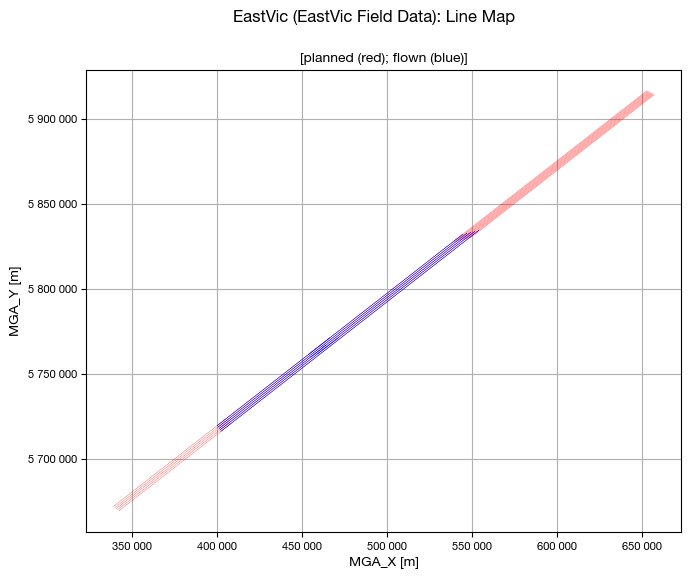

In [47]:
wp.linesMap([EastVicHDF_file], whizzPlanFile=EastVicHDF_plan)

### Blackstump Project Measured Data

In [43]:
mhd.xyzToHDF(Path(stumpXYZ_file), projectName='Blackstump')

Accessing XYZ data in /Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/AirGravQC/examples/SourceData/Blackstump.xyz.
First few records are:
   / ------------------------------------------------------------------------------

   / XYZ EXPORT [04/10/2023]

   / DATABASE   [X:\Bell\70974\Database\Erregulla_AirFTG_FinalDeliverable.gdb]

   / ------------------------------------------------------------------------------

   /

   /    altitude altitude_ftp        Drape eastvelocity      heading     HHMMSS            lat            lon northvelocity        pitch         roll    runnumber    TC100_Txx TC100_Txx_ftp    TC100_Txz TC100_Txz_ftp    TC100_Txy TC100_Txy_ftp    TC100_Tyy TC100_Tyy_ftp    TC100_Tyz TC100_Tyz_ftp    TC100_Tzz TC100_Tzz_ftp      Terrain         time  FAraw_Txx  FAlev_Txx FAlev_Txx_ftp  FAraw_Txz  FAlev_Txz FAlev_Txz_ftp  FAraw_Txy  FAlev_Txy FAlev_Txy_ftp  FAraw_Tyy  FAlev_Tyy FAlev_Tyy_ftp  FAraw_Tyz  FAlev_Tyz FAlev_Tyz_ftp  FAraw_T

PosixPath('/Users/markdransfield/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/AirGravQC/examples/SourceData/Blackstump.hdf5')

In [48]:
block_name = 'Prelim Blackstump Data'
mhd.updateProject(stumpHDF_file, acquirer='Welcome Swallow', blockID=block_name)
mhd.updateCoordFrame(stumpHDF_file, lat='lat', lon='lon', x='X_gda94', y='Y_gda94', time='time', alt='altitude')
mhd.updateCoordFrame(stumpHDF_file, geoDatum='GDA94', htDatum='GDA94', projection='MGA', utmz='50')

Setting BlockID = Prelim Blackstump Data for Blackstump.hdf5.
Setting Acquirer = Welcome Swallow for Blackstump.hdf5.
Changed CoordFrame attribute(s) for Blackstump.hdf5.
Changed CoordFrame attribute(s) for Blackstump.hdf5.


In [44]:
mhd.updateChannelAttributes(stumpHDF_file, 'altitude', units='m')
mhd.updateChannelAttributes(stumpHDF_file, 'altitude_ftp', units='m')
mhd.updateChannelAttributes(stumpHDF_file, 'Drape', units='m', description='Planned Height')
mhd.updateChannelAttributes(stumpHDF_file, 'eastvelocity', units='m/s')
mhd.updateChannelAttributes(stumpHDF_file, 'heading', units='radian')
mhd.updateChannelAttributes(stumpHDF_file, 'lat', units='degree')
mhd.updateChannelAttributes(stumpHDF_file, 'lon', units='degree')
mhd.updateChannelAttributes(stumpHDF_file, 'northvelocity', units='m/s')
mhd.updateChannelAttributes(stumpHDF_file, 'pitch', units='radian')
mhd.updateChannelAttributes(stumpHDF_file, 'roll', units='radian')
mhd.updateChannelAttributes(stumpHDF_file, 'runnumber', description='Flight number')
mhd.updateChannelAttributes(stumpHDF_file, 'Terrain', units='m')
mhd.updateChannelAttributes(stumpHDF_file, 'time', units='s')
mhd.updateChannelAttributes(stumpHDF_file, 'YYMMDD')
mhd.updateChannelAttributes(stumpHDF_file, 'X_gda94', units='metre')
mhd.updateChannelAttributes(stumpHDF_file, 'Y_gda94', units='metre')
mhd.updateChannelAttributes(stumpHDF_file, 'X_wgs84', units='metre')
mhd.updateChannelAttributes(stumpHDF_file, 'Y_wgs84', units='metre')
mhd.updateChannelAttributes(stumpHDF_file, 'FAraw_Txx', units='eotvos')
mhd.updateChannelAttributes(stumpHDF_file, 'FAraw_Txy', units='eotvos')
mhd.updateChannelAttributes(stumpHDF_file, 'FAraw_Txz', units='eotvos')
mhd.updateChannelAttributes(stumpHDF_file, 'FAraw_Tyy', units='eotvos')
mhd.updateChannelAttributes(stumpHDF_file, 'FAraw_Tyz', units='eotvos')
mhd.updateChannelAttributes(stumpHDF_file, 'FAraw_Tzz', units='eotvos')

Changed channel attribute(s) for altitude in Blackstump.hdf5.
Changed channel attribute(s) for altitude_ftp in Blackstump.hdf5.
Changed channel attribute(s) for Drape in Blackstump.hdf5.
Changed channel attribute(s) for eastvelocity in Blackstump.hdf5.
Changed channel attribute(s) for heading in Blackstump.hdf5.
Changed channel attribute(s) for lat in Blackstump.hdf5.
Changed channel attribute(s) for lon in Blackstump.hdf5.
Changed channel attribute(s) for northvelocity in Blackstump.hdf5.
Changed channel attribute(s) for pitch in Blackstump.hdf5.
Changed channel attribute(s) for roll in Blackstump.hdf5.
Changed channel attribute(s) for runnumber in Blackstump.hdf5.
Changed channel attribute(s) for Terrain in Blackstump.hdf5.
Changed channel attribute(s) for time in Blackstump.hdf5.
Changed channel attribute(s) for X_gda94 in Blackstump.hdf5.
Changed channel attribute(s) for Y_gda94 in Blackstump.hdf5.
Changed channel attribute(s) for X_wgs84 in Blackstump.hdf5.
Changed channel attribu

In [49]:
mhd.reportWhizz(stumpHDF_file)

Whizz Version 1.0
    Acquirer: Welcome Swallow
    BlockID: Prelim Blackstump Data
    ProjectName: Blackstump

Coordinates
    AltitudeChannel: altitude
    GeoDatum: GDA94
    HeightDatum: GDA94
    LatitudeChannel: lat
    LongitudeChannel: lon
    Projection: MGA
    TimeChannel: time
    UTMZone: 50
    XChannel: X_gda94
    YChannel: Y_gda94
28 lines: total distance flown [km] = 398.4

28 lines:
 ['101.0', '11.1', '111.1', '121.0', '131.1', '141.0', '151.0', '161.0', '171.1', '181.0', '191.1', '20.0', '201.0', '21.1', '30.0', '31.0', '40.0', '41.1', '50.1', '51.1', '60.0', '61.0', '70.0', '71.1', '80.0', '81.1', '90.0', '91.1']

55 channels:
 ['Drape', 'FAlev_Txx', 'FAlev_Txx_ftp', 'FAlev_Txy', 'FAlev_Txy_ftp', 'FAlev_Txz', 'FAlev_Txz_ftp', 'FAlev_Tyy', 'FAlev_Tyy_ftp', 'FAlev_Tyz', 'FAlev_Tyz_ftp', 'FAlev_Tzz', 'FAlev_Tzz_ftp', 'FAraw_Txx', 'FAraw_Txy', 'FAraw_Txz', 'FAraw_Tyy', 'FAraw_Tyz', 'FAraw_Tzz', 'HHMMSS', 'TC100_Txx', 'TC100_Txx_ftp', 'TC100_Txy', 'TC100_Txy_ftp', 'TC1

In [51]:
mhd.reportFlights(stumpHDF_file, flightChannel='runnumber', detailed=True)

Whizz Version 1.0
    Acquirer: Welcome Swallow
    BlockID: Prelim Blackstump Data
    ProjectName: Blackstump

5 flights including 28 lines.

Flights
    936346075
      L161.0 L181.0 L201.0 
    936397861
      L151.0 L20.0 L30.0 L40.0 L60.0 L70.0 L80.0 L90.0 
    936431254
      L101.0 L121.0 L141.0 L31.0 L61.0 
    936484231
      L11.1 L131.1 L191.1 L41.1 L71.1 L91.1 
    936519318
      L111.1 L171.1 L21.1 L50.1 L51.1 L81.1 



In [52]:
mhd.reportSampling(stumpHDF_file)

Whizz Version 1.0
    Acquirer: Welcome Swallow
    BlockID: Prelim Blackstump Data
    ProjectName: Blackstump

Sample time and distance statistics
  Min   = 1.000 s, 42.3 m
  Max   = 1.040 s, 66.9 m
  Mean  = 1.000 s, 54.2 m
  Stdev = 0.00141 s, 5 m


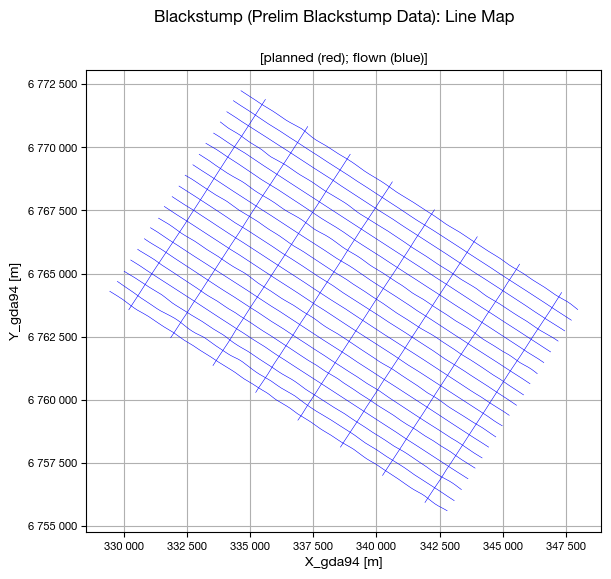

In [53]:
wp.linesMap([stumpHDF_file])

## Reports and formats
<div class="alert alert-block alert-warning">
RECTIFY
<div>

> All of the checks in this section are performed independently of the AirGravQC software and this notebook. But it is convenient to keep all the QC reporting in this one document.

> The acquirer is generally expected to deliver certain reports and data throughout the survey. The data are exxpected in certain formats. This section provides for reporting whether or not these requirements were met.

> Currently this example does not contain any reports. If it did, we would do the following checks.

#### Point located data format
<div class="alert alert-block alert-info">
ACCEPT
<div>

*Delivered point located field data shall be in ASEG-GDF2 format.*

Actually delivered in Geosoft XYZ. For field data this is not a problem so, even though this does not meet contractual requirements, it is acceptable. Channel descriptions file matches actual supplied channels as required.

#### Gridded data format
<div class="alert alert-block alert-info">
NA   
<div>

*The Deed specifies the gridded field data to be supplied. For the Canobie contract, none were required.*

> The Deed specifies ERMapper format.

No grids required and none supplied. Not applicable.

#### Static data to be supplied
<div class="alert alert-block alert-success">
PASS
<div>

*Gravity and navigation processed static readings must be reported to the Customer within 24 hours of every completed flight.*

Quiescent data has been supplied as required. This has been QC'd on a daily basis and no problems, concerns or failings were observed. All data has passed.

#### Field data to be supplied
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed specifies the required channels for field delivery.*

Line data - all required channels delivered.

Channel description text file supplied.

#### Delivered reports
<div class="alert alert-block alert-warning">
TO RECTIFY
<div>

*The Deed requires a Commencement Report before acquisition commences, daily and weekly report through the project, and a final report at the end.*

Commencement report was received in timely manner and was checked against contract. All requirements met.

Daily reports have been received and have provided the information required under the contract.

Weekly reports - none received, supplier has been asked to rectify (email 30 Feb 2019).

Final report - only due at end of project.

#### Coordinates and Units
<div class="alert alert-block alert-info">
ACCEPT
<div>

*As per contract: Correct Coordinate Frame; correct Position Datum, Projected Coordinates and Height Datum; correct units.*

Checked manually.

Coord Frame - PASS

Position Datum - WGS84 incorrect but acceptable for field data.

Projected Coordinate - UTM 54 incorrect (should be MGA 54) but acceptable for field data.

Height Datum - EGM96 geoid incorrect but acceptable for field data.

Units - all correct except gravity which is in mGal instead of µm s<sup>-2</sup>. Accept since field data.

> I accept WGS84/UTM and I accept mGal for field data even though the Deed specifies GDA2020 / MGA and um/s/s. Enforcing the contract makes extra work for the acquirer on every delivery for usually no advantage.

## Navigation and positioning
<div class="alert alert-block alert-info">
ACCEPT
<div>

#### GNSS
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a minimum of 5 GNSS satellites visible for AGG acquisition, and PDOP, HDOP and VDOP to not exceed 4.*

All ok.

In [48]:
qc.checkGNSS(canobieHDF_file, 'NumSats', 'PDOP', 'VDOP', 'HDOP', nsats_min=5, max_pdop=4, 
                  max_hdop=4, max_vdop=4)

In Canobie, checked num sats, PDOP, VDOP and HDOP. Found 0 errors.



> The above exemplifies my preferred reporting structure, with the contractual specification first, then any commentary or summary of QC, and finally, the actual QC check performed with its output. (`checkGNSS()` is the first instance in this notebook with all elements of the structure present.)

> Now, just to see what happens, we increase the required number of satellites to 9. The result is an error report on the one line that failed this more difficult requirement.

In [49]:
qc.checkGNSS(canobieHDF_file, 'NumSats', 'PDOP', 'VDOP', 'HDOP', nsats_min=9, max_pdop=4, 
                  max_hdop=4, max_vdop=4)

In Canobie, checked num sats, PDOP, VDOP and HDOP. Found 1 error.
Line 100050.0 failed for 1097 fids: min sats = 8 < 9. Easting [449313, 495734], Northing [7875826, 7875850].



#### Horizontal Position
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires the horizontal position to not depart from the planned position by more than 40 m for more than 1000 m.*

All ok.

In [50]:
qc.checkXYPlan(canobieHDF_plan, canobieHDF_file, allowance=40.0, maxCounter=0,
               maxDistance=1000.0, plot_flag=False)


0 exceedances known in the database.

0 lines not in plan and not checked.

0 horizontal exceedances.

0 lines with horizontal exceedances.



> Just tightened up the requirement so we can see the report from `checkXYPlan()`.


0 exceedances known in the database.

0 lines not in plan and not checked.

1 horizontal exceedances.

1 lines with horizontal exceedances.

L 100030.00 deviates more than 21.0 m for 162 fids (1237 m), max exceedance = 19 m.
  From (496548 E 7877818 N) to (497785 E 7877818 N).


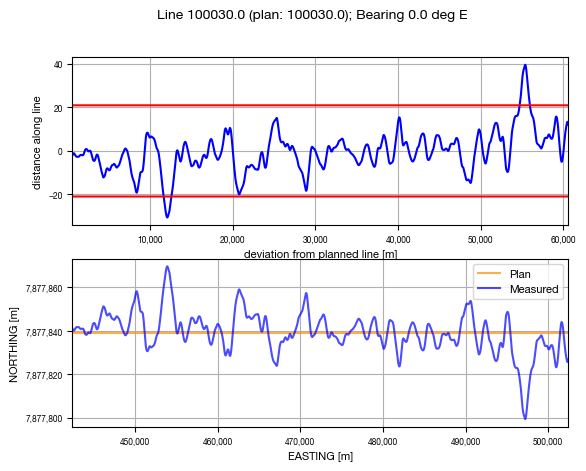

In [51]:
qc.checkXYPlan(canobieHDF_plan, canobieHDF_file, allowance=21.0, maxCounter=0,
               maxDistance=1000.0, plot_flag=True)

#### Vertical Position
<div class="alert alert-block alert-info">
NA
<div>

*The Deed requires the vertical position to not depart from the planned position by more than 20 m for more than 1000 m.*

> I can't find the planned drape for Canobie, but it proceeds very like the horizontal one. Just so you can see what this QC check does, we will run it on the EastVic project data.


0 lines not in plan and not checked.

Total number of exceedances = 3 over 3 erroneous lines.

0 exceedances known in the database.


L 2343.51:1018 deviates more than 20.0 m for 154 fids (4487 m), max exceedance = 152.3 m.
  From (461829 E, 5763999 N) to (465365 E, 5766761 N).
L 2345.50:1018 deviates more than 20.0 m for 179 fids (5170 m), max exceedance = 219.0 m.
  From (464003 E, 5766952 N) to (459909 E, 5763794 N).
L 2345.51:1018 deviates more than 20.0 m for 201 fids (5851 m), max exceedance = 158.2 m.
  From (465437 E, 5768081 N) to (460827 E, 5764478 N).


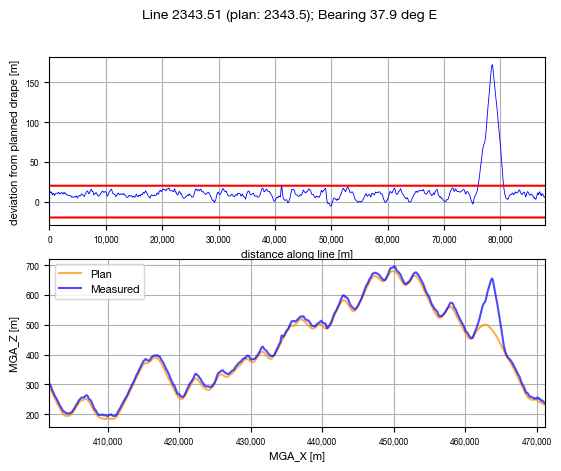

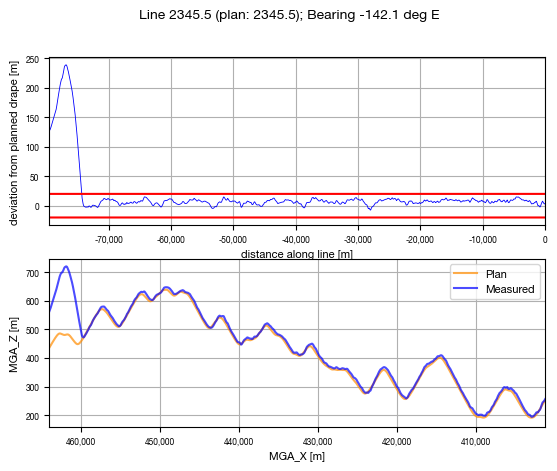

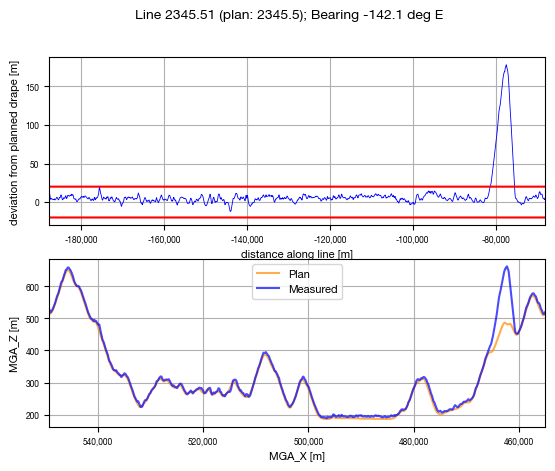

In [52]:
qc.checkVertPlan(EastVicHDF_plan, EastVicHDF_file, allowance=20.0, maxCounter=0,
                 maxDistance=1000.0, plot_flag=True)

#### Cross-over Heights
<div class="alert alert-block alert-info">
NA
<div>

*The Deed requires that the difference in height between traverse and control lines is less than some agreed maximum value.*

There are no control lines at Canobie and no specification so NA.

#### Segment Lengths
<div class="alert alert-block alert-success">
PASS
<div>

*The Deed requires a minimum line segment length. For Canobie, it was 11.2 km.*

OK

In [53]:
qc.checkLineLengths(canobieHDF_file, min_len=11.2)

Number failed lines = 0


#### Line Overlaps
<div class="alert alert-block alert-success">
PASS
<div>

*The minimum overlap between segments of a line should be 600 m for AGG.*

> The report could be more informative here - "all overlaps met the requirement", say

In [54]:
qc.checkOverlaps(canobieHDF_file, min_overlap=0.6, plot_flag=False)

0 coincident lines found.



#### Ground Clearance
<div class="alert alert-block alert-success">
PASS
<div>

*This is a non-contractual check that the aircraft did not approach the ground too closely; it is a simple safety check. The settings check if the aircraft came closer than 60 m from the ground. You can change this to a number of your choice.*

All ok. Also checked at 67 m just to get a plot!

In [55]:
qc.checkSafeClearance(canobieHDF_file, 60.0, altitude_chan='HEIGHT', terrain_chan='DTM')

Number of failed lines = 0.



Number of failed lines = 2.

Clearance too low at 66 m on line 100040.00
Clearance too low at 66 m on line 100060.00


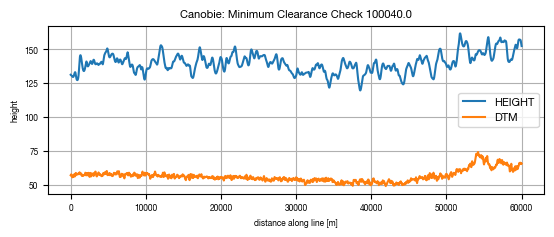

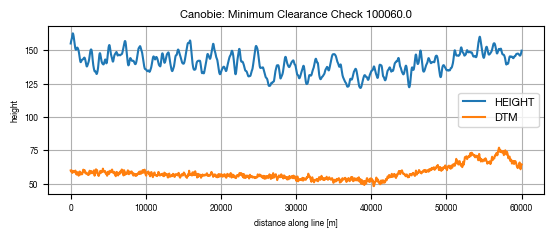

In [56]:
qc.checkSafeClearance(canobieHDF_file, 67.0, altitude_chan='HEIGHT', terrain_chan='DTM')

#### Ground Speed
<div class="alert alert-block alert-success">
PASS
<div>

*The contract requires the ground speed to not exceed the range +/-15% of 60 m/s for more than 1000 m.*

All the data met the specification.

In [57]:
qc.checkSpeeds(canobieHDF_file, nominalSpeed=60., allowance=0.15, maxDistance=1000.0, plot_flag=False)

Velocities not known - will calculate from positions
Nominal ground speed 60.0 m/s; allowed 51.0 : 69.0 for < 1000.0 m.

 Checked 6 lines and 0 had some short exceedance(s).
 0 lines failed for exceedance > allowed.
 Total number of full exceedances = 0.

0 exceedances known in the database.




> Tightening the specification to +/- 6% induces failures so we can see how AirGravQC reports them.

Velocities not known - will calculate from positions
Nominal ground speed 60.0 m/s; allowed 56.4 : 63.6 for < 1000.0 m.

 Checked 6 lines and 25 had some short exceedance(s).
 2 lines failed for exceedance > allowed.
 Total number of full exceedances = 2.

0 exceedances known in the database.


L 100040.00 too slow for 24.25 sec (1353 m), peak exceedance = 55 m/s.
  From (451720 E 7876843 N) to (450367 E 7876845 N).
L 100050.00 too slow for 19.25 sec (1068 m), peak exceedance = 55 m/s.
  From (500760 E 7875851 N) to (501827 E 7875810 N).


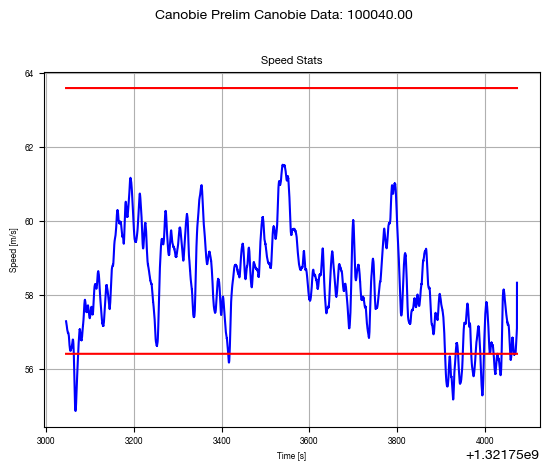

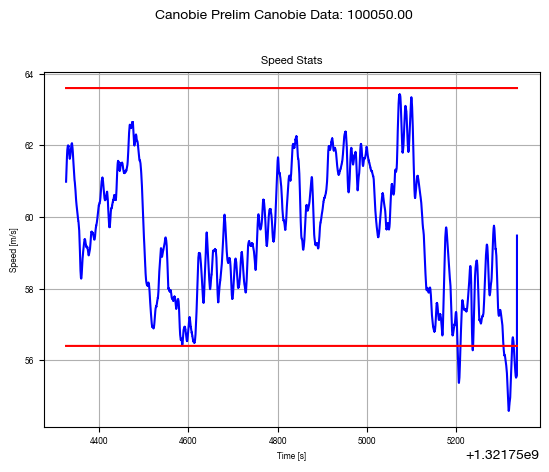

In [58]:
qc.checkSpeeds(canobieHDF_file, nominalSpeed=60., allowance=0.06, maxDistance=1000.0, plot_flag=True)

## Gravimeter
<div class="alert alert-block alert-success">
PASS
<div>

> Canobie was a gradiometer project, so for this section we use the EastVic project data - EastVic was a gravimeter project.

#### Repeat lines
<div class="alert alert-block alert-success">
PASS
<div>

*Contract (p33): "the standard deviation of differences between terrain-corrected vertical gravity values along each repeat line pass and corresponding values from mean of all passes" ... "<= 12.5 µm/s/s for any individual pass" and "<= 7 µm/s/s for all passes combined."*

All repeat lines pass with the worst repeatability being 11.1 µm s<sup>-2</sup>.

Repeatability of vertical position was excellent, with RMS differences around 4 m for all lines.

In [59]:
all_lines = ['7001.16', '7001.17', '7001.18', '7001.19', '7001.2', '7001.21',
             '7001.22', '7001.23', '7001.24', '7001.25']

10 lines analysed, each with 1704 samples.
Line 7001.16 heading = 134.7 deg.
Line 7001.17 heading = -45.3 deg.
Line 7001.18 heading = 134.7 deg.
Line 7001.19 heading = -45.3 deg.
Line 7001.2 heading = 134.7 deg.
Line 7001.21 heading = -45.3 deg.
Line 7001.22 heading = 134.7 deg.
Line 7001.23 heading = -45.3 deg.
Line 7001.24 heading = -45.3 deg.
Line 7001.25 heading = 134.7 deg.
Line 7001.16: stdev(B100s-267_GEOID) = 0.61 mGal
Line 7001.17: stdev(B100s-267_GEOID) = 0.63 mGal
Line 7001.18: stdev(B100s-267_GEOID) = 0.59 mGal
Line 7001.19: stdev(B100s-267_GEOID) = 0.45 mGal
Line 7001.2: stdev(B100s-267_GEOID) = 0.80 mGal
Line 7001.21: stdev(B100s-267_GEOID) = 0.76 mGal
Line 7001.22: stdev(B100s-267_GEOID) = 0.93 mGal
Line 7001.23: stdev(B100s-267_GEOID) = 0.78 mGal
Line 7001.24: stdev(B100s-267_GEOID) = 1.11 mGal
Line 7001.25: stdev(B100s-267_GEOID) = 1.03 mGal
Line 7001.16: stdev(MGA-Z) = 3.8 m
Line 7001.17: stdev(MGA-Z) = 4.1 m
Line 7001.18: stdev(MGA-Z) = 4.5 m
Line 7001.19: stdev(MGA-

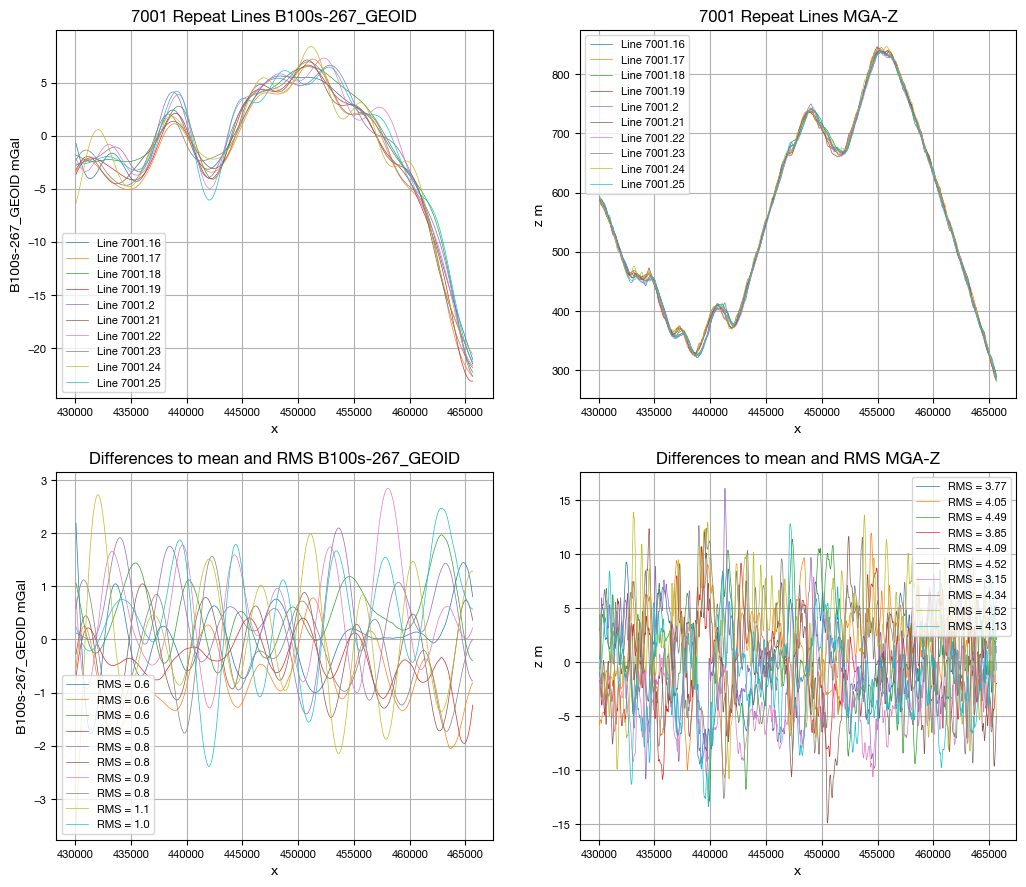

In [60]:
qc.checkRepeatLines(EastVicRepHDF_file, 'B100s-267_GEOID', all_lines, xOffset=False)

#### Test lines
<div class="alert alert-block alert-success">
PASS
<div>

First check repeatability - which is very good.

In [61]:
all_lines = ['8001.04', '8001.05', '8001.06', '8001.07']

4 lines analysed, each with 1691 samples.
Line 8001.04 heading = 52.2 deg.
Line 8001.05 heading = -127.9 deg.
Line 8001.06 heading = -127.9 deg.
Line 8001.07 heading = 52.2 deg.
Line 8001.04: stdev(B100s-267_GEOID) = 0.40 mGal
Line 8001.05: stdev(B100s-267_GEOID) = 0.46 mGal
Line 8001.06: stdev(B100s-267_GEOID) = 0.36 mGal
Line 8001.07: stdev(B100s-267_GEOID) = 0.31 mGal
Line 8001.04: stdev(MGA-Z) = 3.0 m
Line 8001.05: stdev(MGA-Z) = 3.1 m
Line 8001.06: stdev(MGA-Z) = 3.1 m
Line 8001.07: stdev(MGA-Z) = 3.5 m


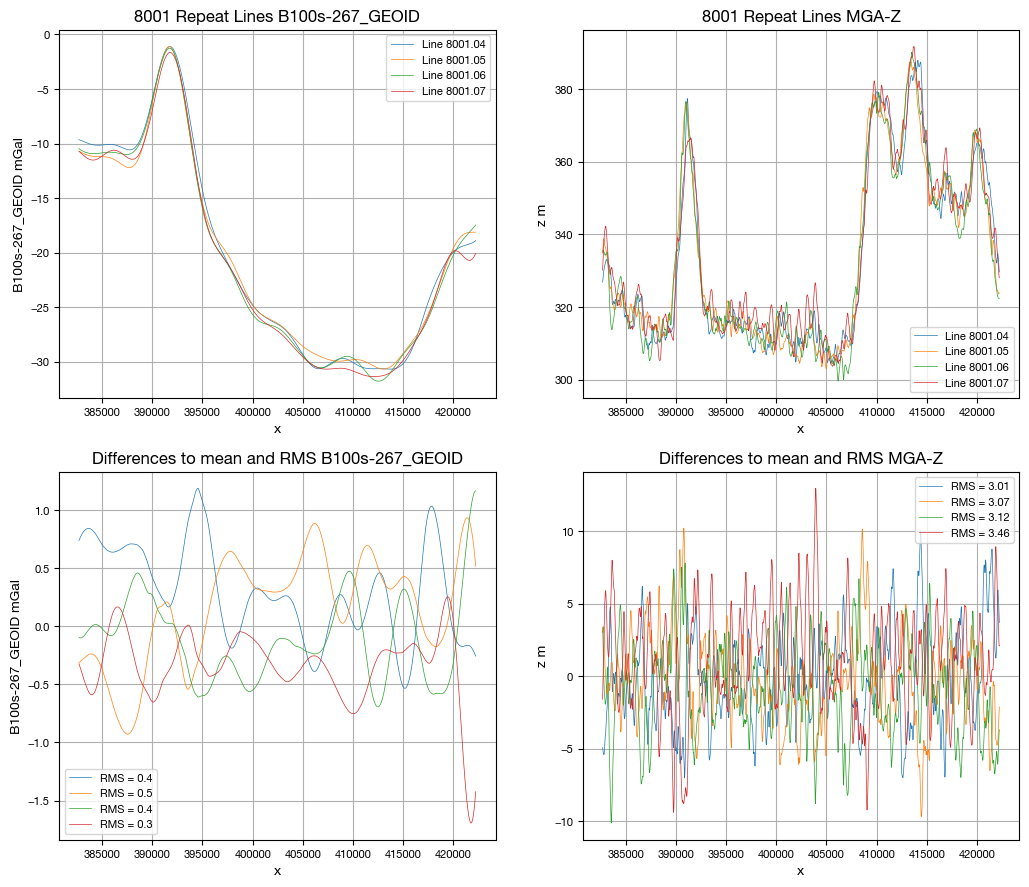

In [62]:
qc.checkRepeatLines(EastVicTestHDF_file, 'B100s-267_GEOID', all_lines, xOffset=False)

Next, compare with ground gravity grid sampled onto a flight line. I downloaded the ground gravity grid from GADDS.

In [63]:
grid_path = Path(data_root + r'Gravmap2019-grid-grv_cscba-IncludesAirborne.ers')

32 bit precision

Grid file read for channel  Gravmap2019-grid-grv_cscba-IncludesAirborne
  SW Corner =  5953432.5 370462.5   NE Corner =  6000157.5 438102.5 . Spacings =  445.0 445.0
Line 8001.04
  North min, max  5966297.68 5997023.88   East min, max  382668.99 422214.88
Stdev(diff) = 106.4


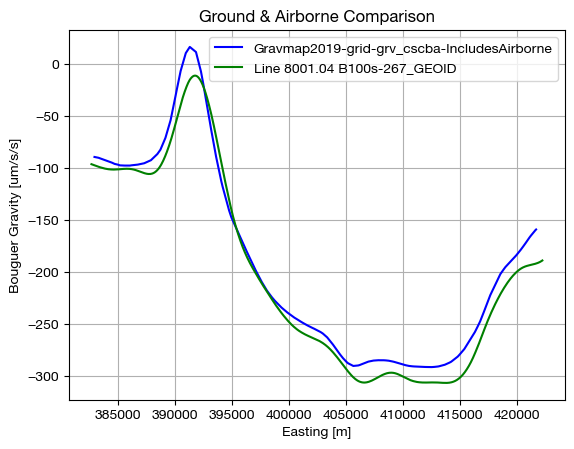

In [64]:
qc.diffGroundGrid(EastVicTestHDF_file, 'B100s-267_GEOID', '8001.04', grid_path, plot_title='Ground & Airborne Comparison')

The data look very similar but the differences are up to ~ 10 µm s<sup>-2</sup> or more. Let's see how good the ground gravity are.

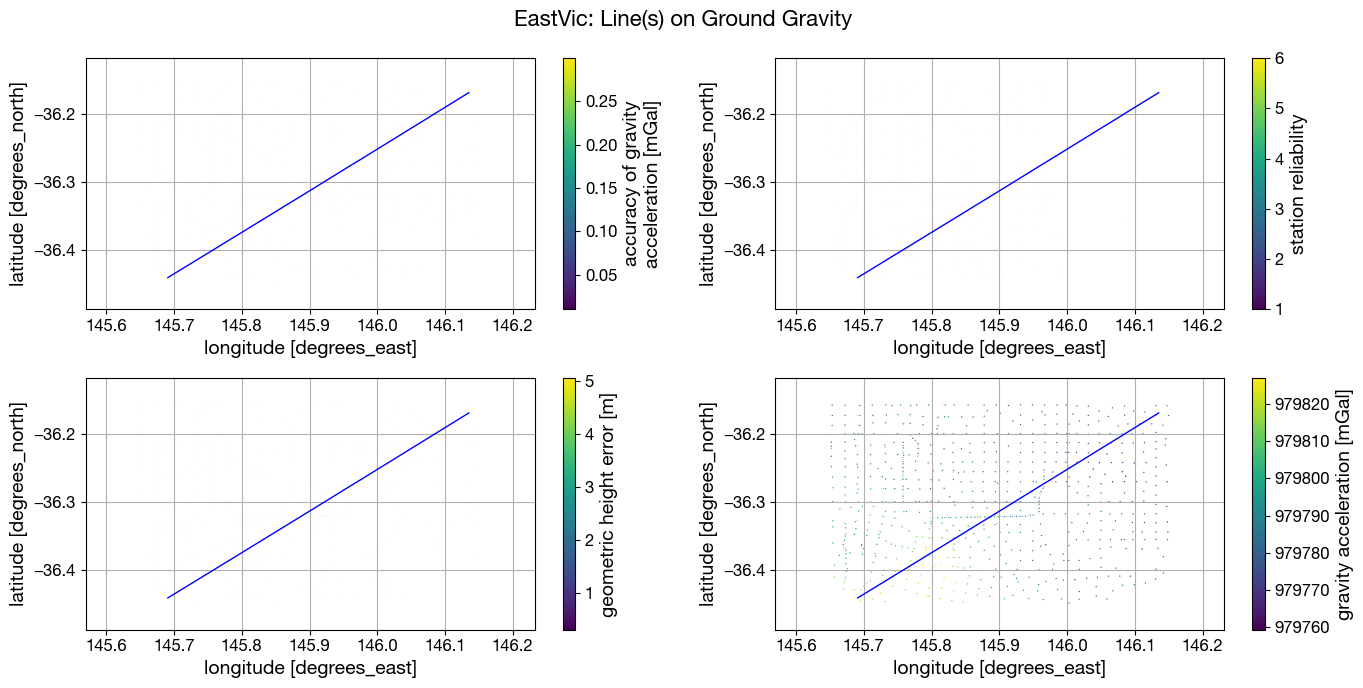

In [65]:
wp.plotLinesOnGroundStns(EastVicTestHDF_file, '8001.04', minlon=145.65, maxlon=146.15,
                         minlat=-36.45, maxlat=-36.15, min_reliability=0, fig_title='')

The ground gravity information is downloaded live from GA. The accuracy, reliability and height error information seem to be missing here but we can see the station locations. The data are relatively sparse so some of the difference is likely due to interpolation error from gridding the ground gravity. Some may be due to error in the airborne data.

#### Line Intersections
<div class="alert alert-block alert-success">
PASS
<div>

> TBD

#### Static data
<div class="alert alert-block alert-success">
PASS
<div>

*The specification says ...*

Static gravimeter data pre- and post-flight were supplied each day of flying as required and all met the specification.

#### Atmospheric corrections
<div class="alert alert-block alert-success">
PASS
<div>

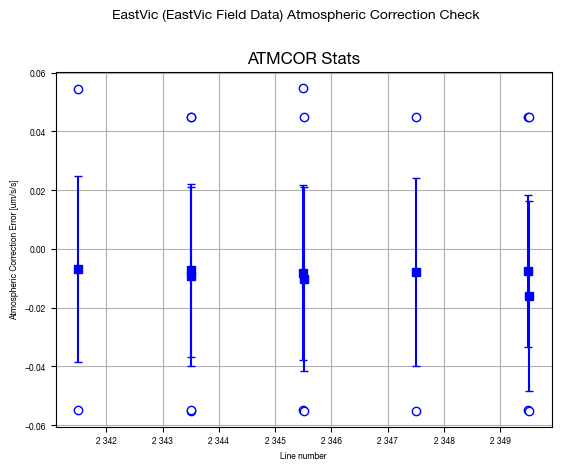

In [66]:
qc.checkAtmosEffect(EastVicHDF_file, 'ATMCOR', GRS80_height='MGA_Z')

#### Free-air corrections
<div class="alert alert-block alert-success">
PASS
<div>

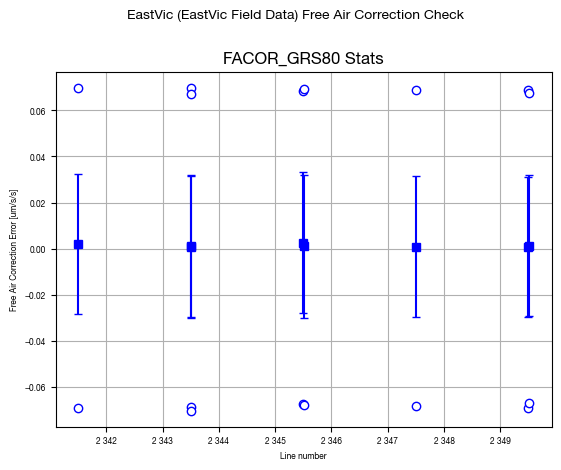

In [67]:
qc.checkFreeAirCorr(EastVicHDF_file, 'FACOR_GRS80')

#### Eotvos corrections
<div class="alert alert-block alert-success">
PASS
<div>

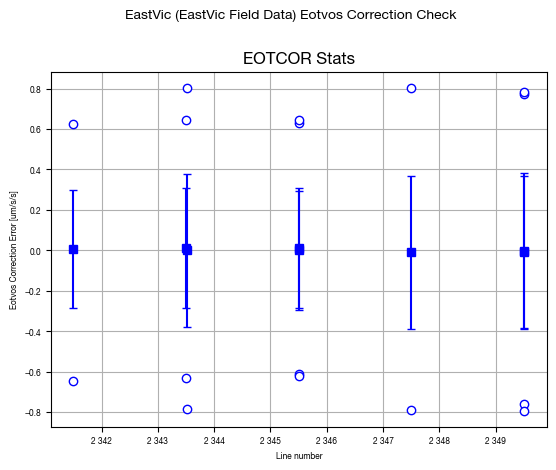

In [68]:
qc.checkEotvosCorr(EastVicHDF_file, 'EOTCOR', east_vel='V_EAST', north_vel='V_NORTH')

#### Latitude corrections
<div class="alert alert-block alert-success">
PASS
<div>

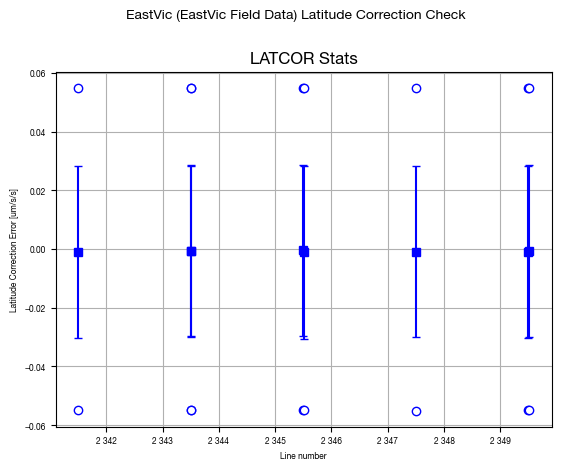

In [69]:
qc.checkLatCorr(EastVicHDF_file, 'LATCOR')

#### Aircraft Accelerations
<div class="alert alert-block alert-success">
PASS
<div>

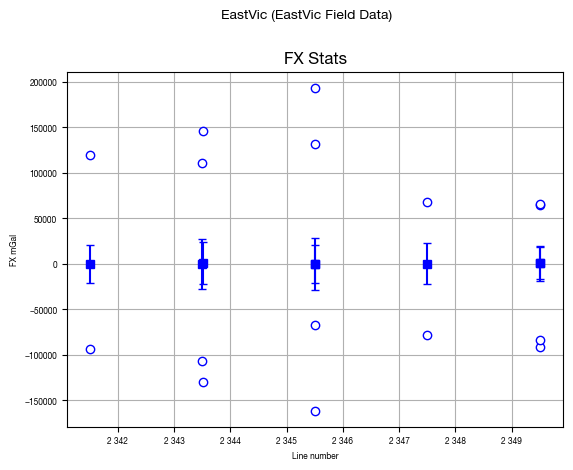

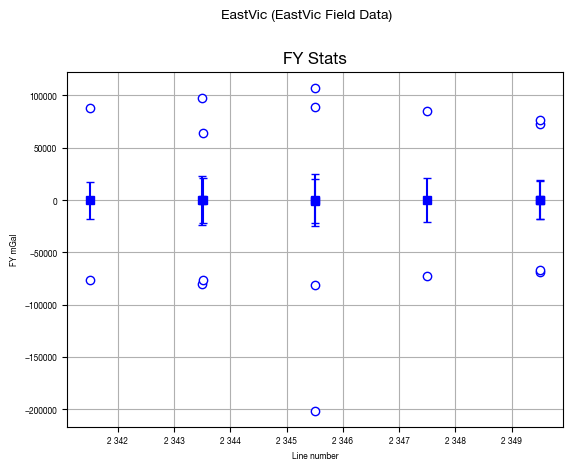

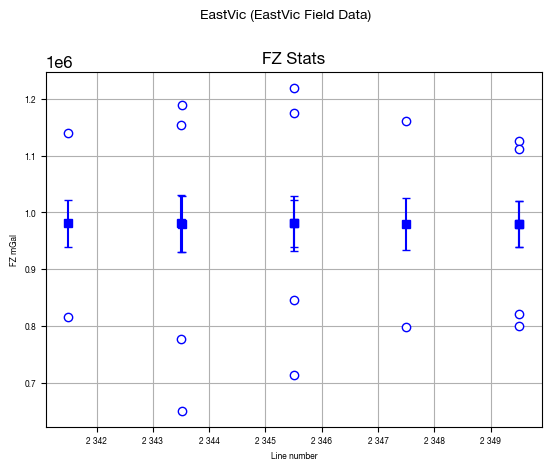

In [70]:
qc.allChanStats(EastVicHDF_file,allChannels=['FX', 'FY', 'FZ'])

## AGG Gradiometer
<div class="alert alert-block alert-success">
PASS
<div>

#### Quiescent Noise
<div class="alert alert-block alert-success">
PASS
<div>

*Deed requires quiescent data collected before each flight and the results delivered in the the daily report. Average signal power density over both complements is required to be below $10E^{2}/rad/sec$.*

Quiescent data were supplied daily by email as required and were checked on arrival. All quiescent data was below 10 E^2/r/s as required.

#### AGG Noise
<div class="alert alert-block alert-success">
PASS
<div>

*Deed requires that any line with an average noise above 5.0 E be re-flown.*

OK

> The noise depends on turbulence so it is instructive to plot each noise channel against turbulence. This also shows any outliers from the general trend (There are too few lines to see a trend here.)

> Although the specification is 5.0 E, let's set it to 2.5 E so that we get a line to fail. If we set labelLines=True, then all failed lines are labeled on the plot.

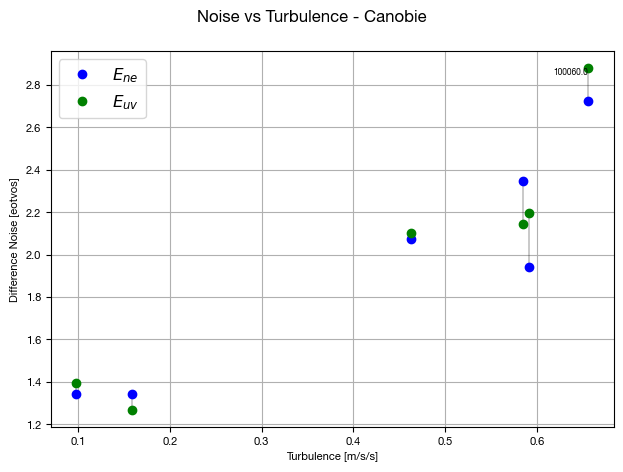

100060.0 fails with noise 2.80 > 2.5, mean turbulence = 0.66.



In [71]:
qc.diffNoiseVturb(canobieHDF_file, eNE='Noise_NE', eUV='Noise_UV', turbulence='TURBULENCE',
                  error_spec=2.5, labelLines=True)

> Any rectification process can down-convert high frequency vibration into the signal band of a sensor. Gravity gradiometers have an intrinsic rectification process via their sensitivity to products of rotational velocity so it is useful to check for excess high frequency signal since it may lead to error in the final data.

> For the AGG system, a noiseLimit of ~15 E ought to be followed up with the acquisition company. Here I set the noiseLimit much lower in order to demonstrate the plotting of the result.

> The raw gradients are high-pass filtered and a rolling standard deviation is used to find periods of higher amplitudes. Turbulence is a likely cause of excess vibration so the turbulence is also plotted for comparison.

> This is not a contractual check in the Deed.

Line 100010.0 Noise: ANE_TC_2p67 = 3.0; AUV_TC_2p67 = 3.6; BNE_TC_2p67 = 2.7; BUV_TC_2p67 = 2.6; 
Line 100020.0 Noise: ANE_TC_2p67 = 1.4; AUV_TC_2p67 = 1.7; BNE_TC_2p67 = 1.7; BUV_TC_2p67 = 1.7; 


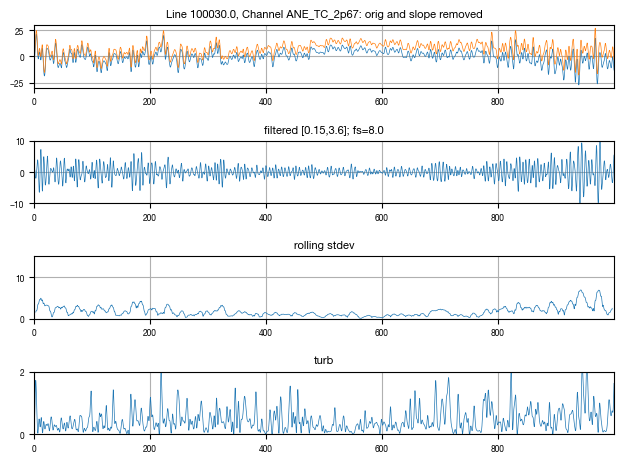

Line 100030.0 Noise: ANE_TC_2p67 = 6.9; AUV_TC_2p67 = 6.4; BNE_TC_2p67 = 4.6; BUV_TC_2p67 = 5.4; 
Line 100040.0 Noise: ANE_TC_2p67 = 3.4; AUV_TC_2p67 = 3.2; BNE_TC_2p67 = 2.9; BUV_TC_2p67 = 2.7; 
Line 100050.0 Noise: ANE_TC_2p67 = 3.7; AUV_TC_2p67 = 3.1; BNE_TC_2p67 = 4.0; BUV_TC_2p67 = 4.4; 
Line 100060.0 Noise: ANE_TC_2p67 = 5.4; AUV_TC_2p67 = 4.9; BNE_TC_2p67 = 6.4; BUV_TC_2p67 = 5.4; 


In [72]:
qc.checkRawAGG(canobieHDF_file, 'ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'TURBULENCE', noiseLimit=6.5)

## FTG Gradiometer
<div class="alert alert-block alert-info">
ACCEPT
<div>

> `AirGravQC` includes functions for the QC of FTG data but we do not have field data available to test it on. Instead we will "fake it to make it".

FTG data in the field is delivered with the raw in-line and cross gradients and it is these channels that the following QC functions check. The final data does not include the in-line and cross data and all delivered gradients have been filtered and transformed to components of the tensor representation. The transformation exploits Laplace's equation which means that the ensor trace is, by construction, zero. This makes all the tests against the trace useless.

So these examples would be much more realistic with the raw in-line and cross gradients. Nevertheless, some can be run with the supplied final components and this is done here to demonstrate the use of the functions. The results are, however, meaningless.

> `ilsNoiseVturb()` performs the same task as `diffNoiseVturb()` does for AGG but it uses the in-line sum as the measure of noise instead of the difference noise.

Here we get very low noise estimates because we are inputting (despite the channel names) final transformed data.

101.0   0.0013125955488547882
11.1   0.0011454850646977442
111.1   0.0011171086056907384
121.0   0.0009970448777193509
131.1   0.001229285876468645
141.0   0.0008592346972897051
151.0   0.0009264894210961877
161.0   0.001037932433641635
171.1   0.0012162273458576234
181.0   0.0010123566543093143
191.1   0.0010946743033822528
20.0   0.0012456752602179203
201.0   0.0011235527496312094
21.1   0.0014125454466230696
30.0   0.0009417787181303747
31.0   0.001040587003534119
40.0   0.0010662890318277416
41.1   0.0008734257274137196
50.1   0.001176479932202678
51.1   0.001039549835046557
60.0   0.0008867164174283291
61.0   0.0010900714989210713
70.0   0.001053101181921084
71.1   0.001108876111439374
80.0   0.0011298879533108654
81.1   0.0008225147449443166
90.0   0.0008997777356771227
91.1   0.0009709852447164848


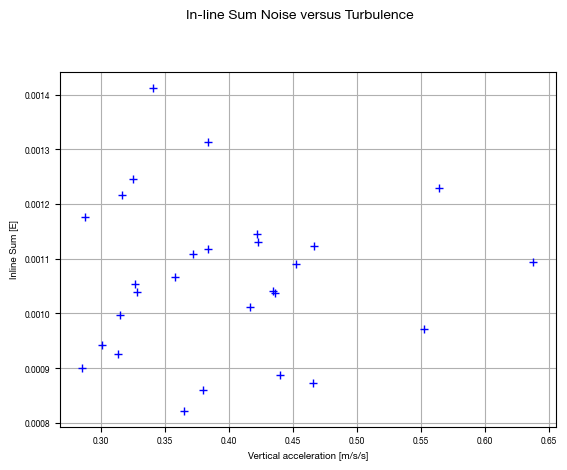

In [86]:
qc.ilsNoiseVturb(stumpHDF_file, 'FAraw_Txx', 'FAraw_Tyy', 'FAraw_Tzz', vertdispl='altitude')

> `checkRawFTG()` performs the same task as `checkRawAGG()` but using the raw FTG in-line and cross channels.

The aim is to check for periods of excess high frequency noise. The usual `noiseLimit` is 50 but the final data used as input to the function have been heavily filtered and so it has been set to 30 here just to get some plots.

Line 101.0 Noise: FAraw_Txx = 22.5; FAraw_Tyy = 19.4; FAraw_Tzz = 22.1; 
Line 11.1 Noise: FAraw_Txx = 18.4; FAraw_Tyy = 15.8; FAraw_Tzz = 21.0; 
Line 111.1 Noise: FAraw_Txx = 27.4; FAraw_Tyy = 28.5; FAraw_Tzz = 29.4; 
Line 121.0 Noise: FAraw_Txx = 20.2; FAraw_Tyy = 16.0; FAraw_Tzz = 21.5; 
Line 131.1 Noise: FAraw_Txx = 26.3; FAraw_Tyy = 19.7; FAraw_Tzz = 29.9; 
Line 141.0 Noise: FAraw_Txx = 20.4; FAraw_Tyy = 13.9; FAraw_Tzz = 24.9; 
Line 151.0 Noise: FAraw_Txx = 23.2; FAraw_Tyy = 17.8; FAraw_Tzz = 22.9; 
Line 161.0 Noise: FAraw_Txx = 18.1; FAraw_Tyy = 25.5; FAraw_Tzz = 23.1; 
Line 171.1 Noise: FAraw_Txx = 26.0; FAraw_Tyy = 20.3; FAraw_Tzz = 23.5; 
Line 181.0 Noise: FAraw_Txx = 14.7; FAraw_Tyy = 16.1; FAraw_Tzz = 19.5; 


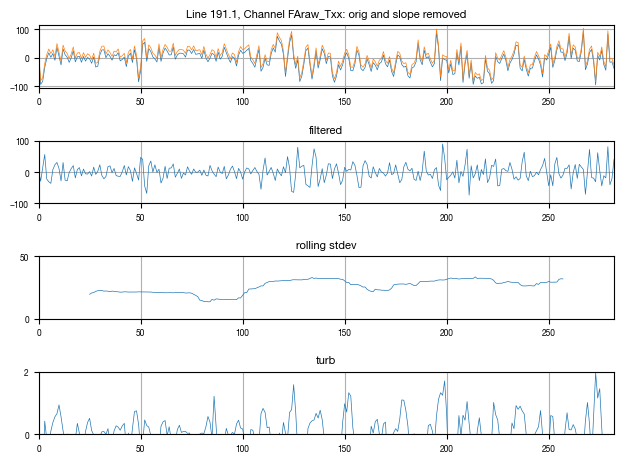

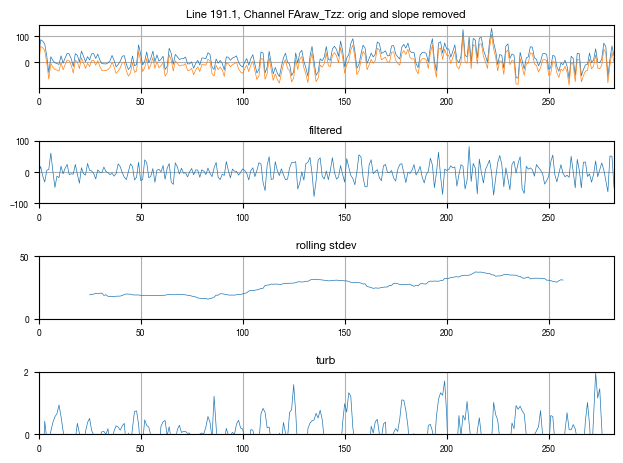

Line 191.1 Noise: FAraw_Txx = 33.5; FAraw_Tyy = 27.9; FAraw_Tzz = 37.5; 
Line 20.0 Noise: FAraw_Txx = 12.1; FAraw_Tyy = 11.2; FAraw_Tzz = 13.1; 
Line 201.0 Noise: FAraw_Txx = 20.7; FAraw_Tyy = 19.4; FAraw_Tzz = 21.2; 
Line 21.1 Noise: FAraw_Txx = 24.7; FAraw_Tyy = 17.7; FAraw_Tzz = 20.3; 
Line 30.0 Noise: FAraw_Txx = 20.9; FAraw_Tyy = 15.7; FAraw_Tzz = 19.8; 
Line 31.0 Noise: FAraw_Txx = 23.8; FAraw_Tyy = 17.8; FAraw_Tzz = 22.9; 
Line 40.0 Noise: FAraw_Txx = 20.8; FAraw_Tyy = 16.9; FAraw_Tzz = 22.7; 
Line 41.1 Noise: FAraw_Txx = 22.9; FAraw_Tyy = 18.9; FAraw_Tzz = 25.5; 
Line 50.1 Noise: FAraw_Txx = 16.6; FAraw_Tyy = 17.3; FAraw_Tzz = 20.1; 
Line 51.1 Noise: FAraw_Txx = 23.9; FAraw_Tyy = 19.3; FAraw_Tzz = 23.3; 
Line 60.0 Noise: FAraw_Txx = 19.7; FAraw_Tyy = 21.7; FAraw_Tzz = 21.7; 
Line 61.0 Noise: FAraw_Txx = 24.5; FAraw_Tyy = 18.2; FAraw_Tzz = 25.8; 
Line 70.0 Noise: FAraw_Txx = 16.8; FAraw_Tyy = 18.0; FAraw_Tzz = 21.2; 
Line 71.1 Noise: FAraw_Txx = 18.2; FAraw_Tyy = 22.6; FAraw_Tzz

In [87]:
qc.checkRawFTG(stumpHDF_file, lines=[], gradients=['FAraw_Txx', 'FAraw_Tyy', 'FAraw_Tzz'], noiseLimit=30, vertdispl='altitude')

> `checkInlineSum()` calculates the in-line sum from the raw FTG in-line channels, plotting and reporting results.

The inputs are transformed gradients and so are constructed using Laplace's equation. Consequently the in-line sum is, by construction, zero and so this is not a true test. It does work if applied to the in-line components delivered in field data.

The non-zero values are due to the conversion of the data into text in the `XYZ` files.

101.0  STD BPF =  0.003018874260148145
11.1  STD BPF =  0.0028736880455883518
111.1  STD BPF =  0.0027174664942565324
121.0  STD BPF =  0.0028768486837414367
131.1  STD BPF =  0.003160915149865833
141.0  STD BPF =  0.002812726509287262
151.0  STD BPF =  0.0027234039760108708
161.0  STD BPF =  0.0027130560215033227
171.1  STD BPF =  0.002837949757061485
181.0  STD BPF =  0.002842001470520992
191.1  STD BPF =  0.002857169612965937
20.0  STD BPF =  0.0029120355467276804
201.0  STD BPF =  0.0029256820045138895
21.1  STD BPF =  0.0030927404415015216
30.0  STD BPF =  0.0027870408742342073
31.0  STD BPF =  0.0032115400575728377
40.0  STD BPF =  0.0030058168474482224
41.1  STD BPF =  0.0026813919926582538
50.1  STD BPF =  0.002766259845074894
51.1  STD BPF =  0.002741676725321102
60.0  STD BPF =  0.0029382526260862394
61.0  STD BPF =  0.0030459738806028844
70.0  STD BPF =  0.0029632624722028523
71.1  STD BPF =  0.0030762679732884556
80.0  STD BPF =  0.002689561580741088
81.1  STD BPF =  0.0028

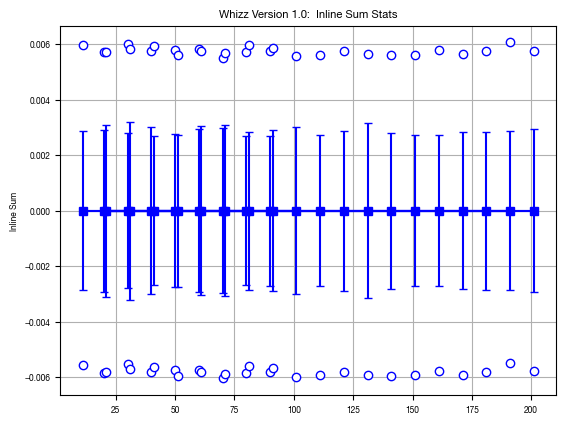

In [88]:
qc.checkInlineSum(stumpHDF_file, inline1='FAraw_Txx', inline2='FAraw_Tyy', inline3='FAraw_Tzz', dontfilter=True)

> `eigenPlot()` checks the Frobenius norm of the tensor and plots results if it exceeds the noise limit.

It relies on having the raw inline and cross gradients which we do not have in the Blackstump data-set and their is no sensible way to fake it here.

In [107]:
# qc.eigenPlot(stumpHDF_file, lines = [], noiselimit=30.0)

## Statistics and Grids
<div class="alert alert-block alert-info">
NA
<div>

#### Data Quality
<div class="alert alert-block alert-success">
PASS
<div>

*None of the following checks are contractually required but they can give some insights to data quality.*

---
The only spikes found were at very small amplitudes on otherwise smooth fields (terrain corrections). All ok.

> The following channels should vary smoothly without spikes. You can choose different channels to test for your project but I have found this test to generally be too sensitive. The algorithm could be improved.

In [73]:
qc.checkSpikes(canobieHDF_file, fields=['Bearing', 'Noise_NE', 'Noise_UV', 'gD_Fourier_2p67', 'T_DD', 'T_NE', 'T_UV', \
                            'LATITUDE', 'LONGITUDE', 'EASTING', 'NORTHING', 'DTM'])

---
The only failures are in the `Time_Day` channel and all are within 1 second of midnight. Time of day does not vary with constant slope at midnight so this is not a concern. Of course the aircraft was not flying at midnight, suggesting the the relevant clock is in the wrong time zone but this is not a concern.

> The checked fields should each vary uniformly with constant slope.

In [74]:
qc.checkConstantSlope(canobieHDF_file, fields=['Date', 'FIDUCIAL', 'FLIGHT', 'LINE', 'Time_Day', 'JOB_ID', \
                                   'Time_1980'])


  100010.0; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100010.0; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100020.0; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100020.0; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100030.0; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100030.0; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100040.0; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100040.0; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100050.0; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100050.0; Time_1980 Largest difference (= 0.000999) > 0.1% of mean difference (= 0.00125)
  100060.0; Time_Day Largest difference (= 0.000999) > 0.1% of mean difference (= 0.

---
All channel statistics look as expected. OK.

> Just plot the mean, standard deviation and range of every channel as a for every line. A lot of information condensed here which I find useful. I just run my eye quickly over the plots looking for outliers, and I check the vertical scales to ensure that the values are in about the right range.

In [ ]:
# Normally, plot the stats for all channels whatsoever. But to save space, we will just do a few in the next notebook cell, and comment this one out.
# qc.allChanStats(canobieHDF_file, ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing',
#                      'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67',
#                      'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE',
#                      'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP',
#                      'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67'])

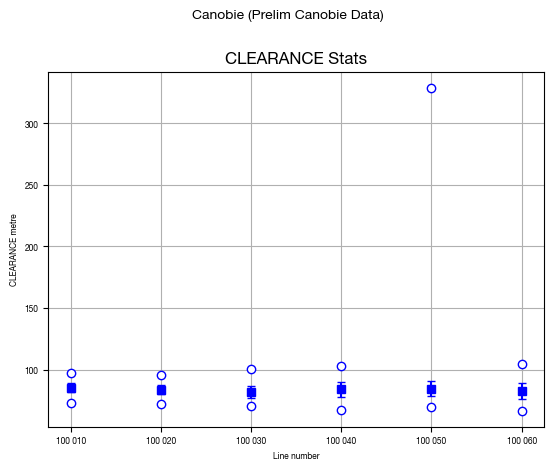

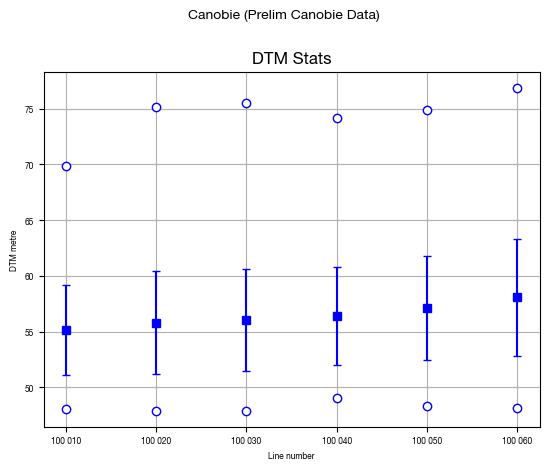

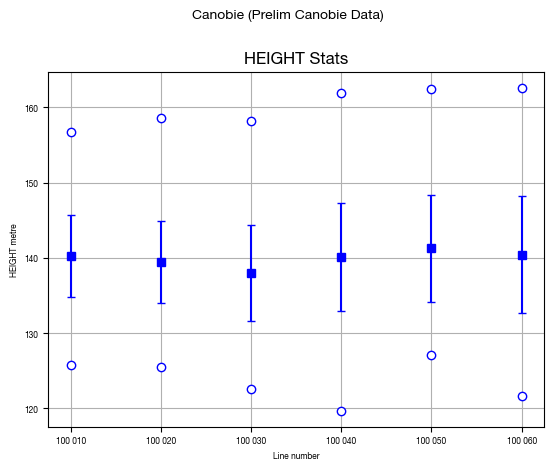

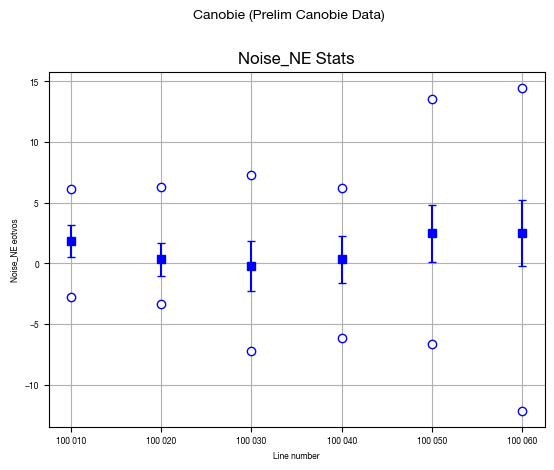

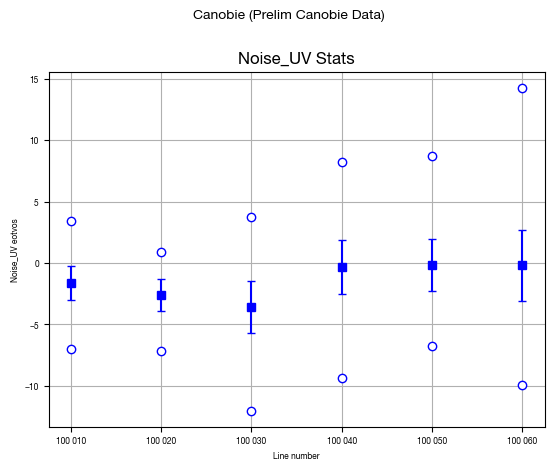

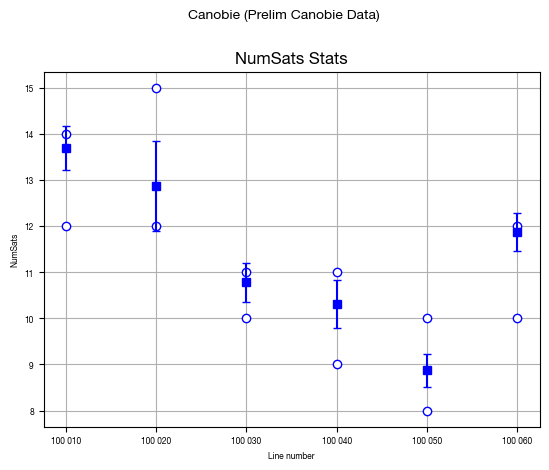

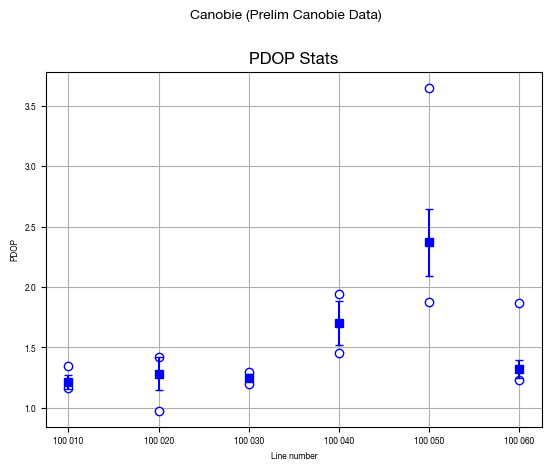

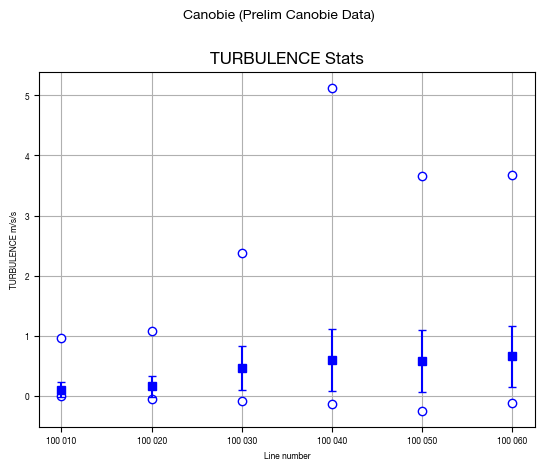

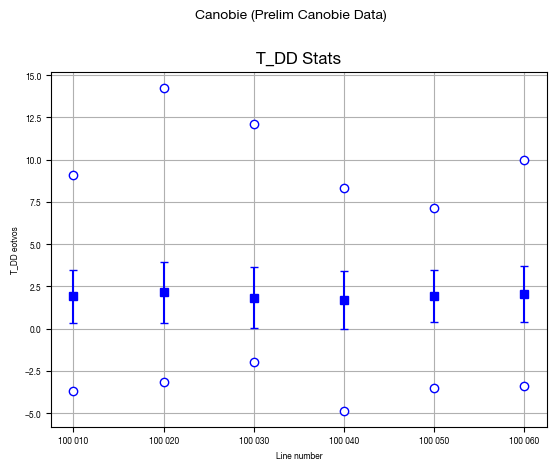

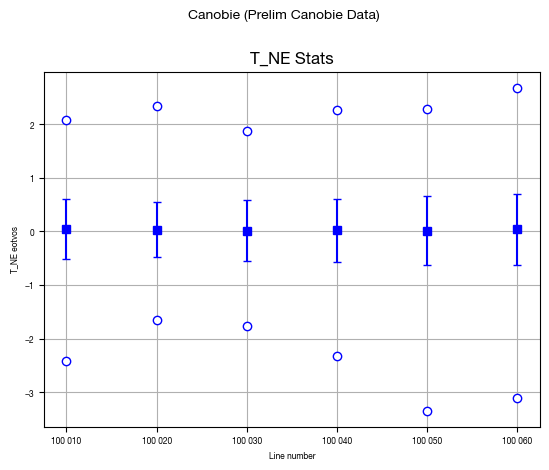

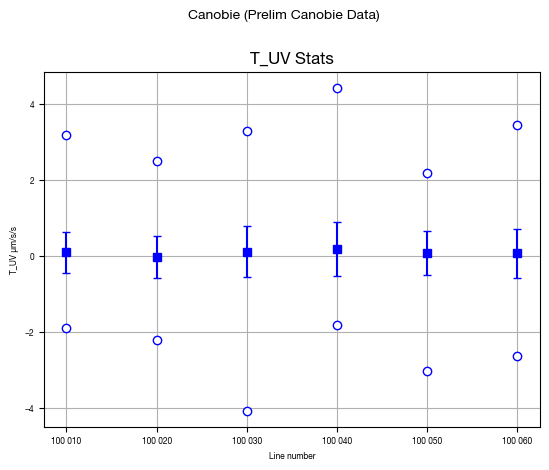

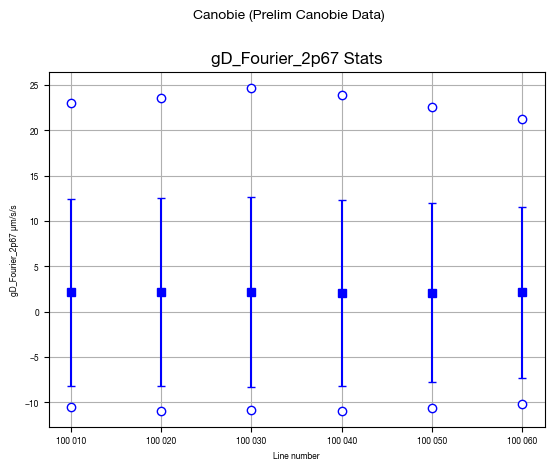

In [75]:
qc.allChanStats(canobieHDF_file, ['CLEARANCE', 'DTM', 'HEIGHT', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP',
                     'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'gD_Fourier_2p67'])

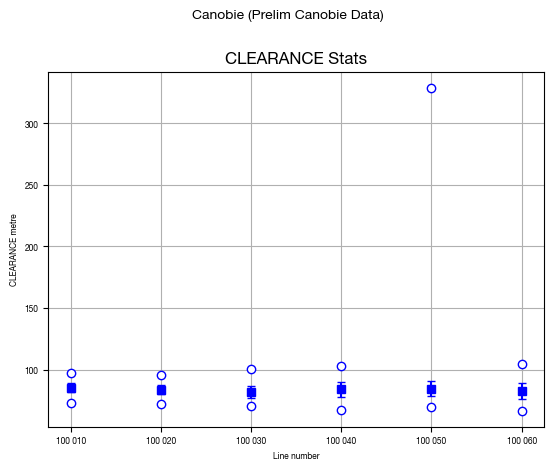

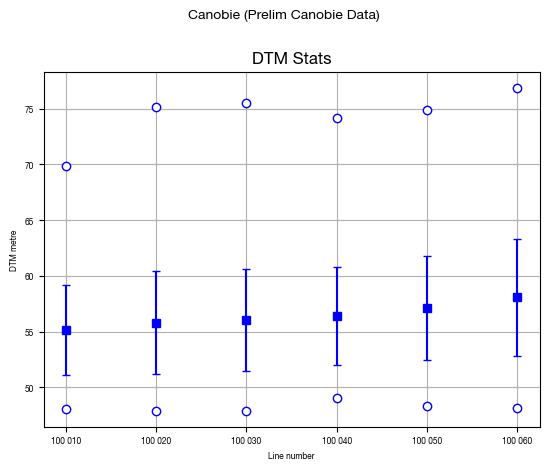

In [76]:
qc.allChanStats(canobieHDF_file, ['CLEARANCE', 'DTM'])

#### Even-Odd Grids
<div class="alert alert-block alert-info">
NA
<div>

> Currently, `AirGravQC` does not have a capacity to separately grid odd and even lines, then analyse the difference between the grids.

#### Delivered Grids
<div class="alert alert-block alert-info">
NA
<div>

*For Canobie, there was no requirement for grids of field data to be delivered and none were.*

> The Deed does not have specifications on the quality of gridded field data but grids are a quick and easy way to spot any artefacts in the data. So they are useful in checking for "best practice".

> The function `checkErsHeaders()` is useful when there are supplied grids.

> In any case, I always generate grids from the located data.

In [ ]:
# qc.checkErsHeaders(ersp)

#### Generated Grids
<div class="alert alert-block alert-success">
PASS
<div>

*There are no Deed specifications on the grids except "best practice".*

All the grids look okay and there are no serious artefacts.

> I grid and image almost every channel in the database (here I have only done a few as examples). Channels that are directionally dependent have the mean for each line removed ("mr") before gridding. For some channels it is more useful to examine the grid of the first difference along each line ("d1").

> It might be useful to comment on some particular images.

Gridding and imaging Bearing
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, MR_Bearing). MR_Bearing in degrees.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (-2.151, 2.383)


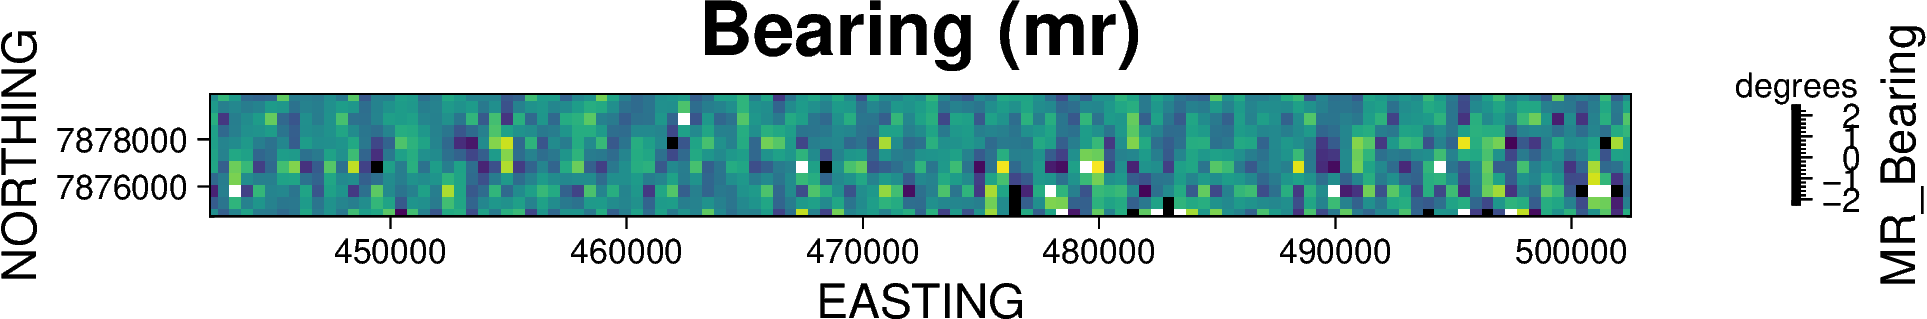

Gridding and imaging CLEARANCE
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, CLEARANCE). CLEARANCE in metre.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (72.59, 93.39)


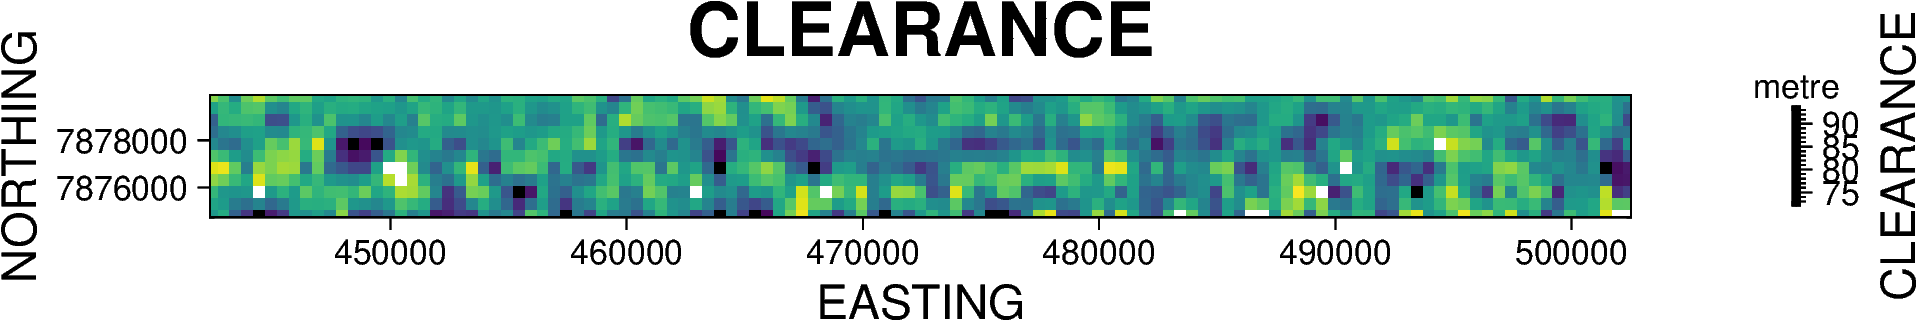

Gridding and imaging DTM
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, DTM). DTM in metre.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (50.15, 71.51)


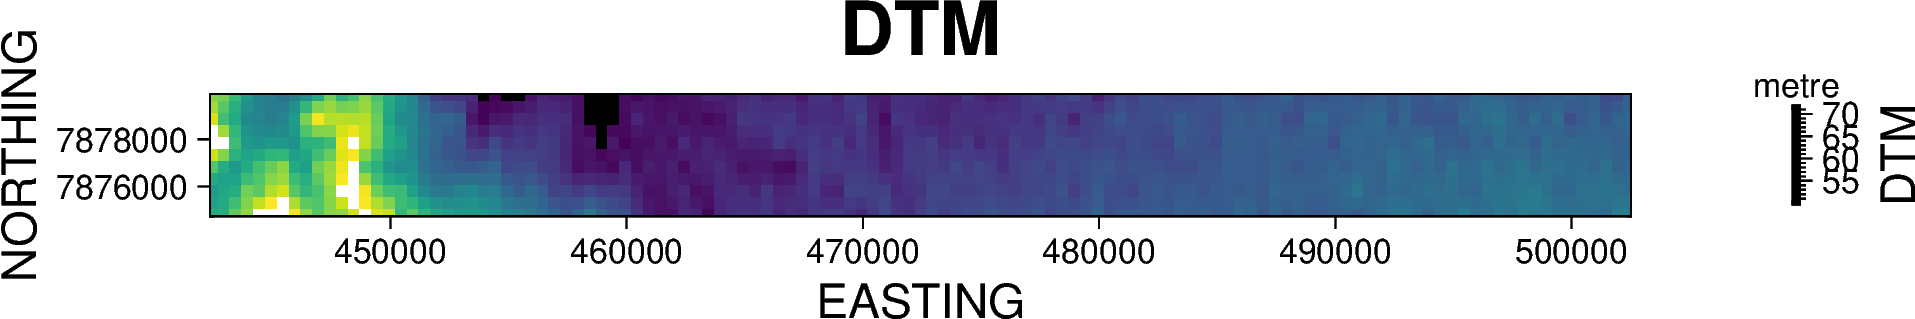

Gridding and imaging FLIGHT
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, D1_FLIGHT). D1_FLIGHT in -.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]


surface [WARNING]: Input data lie exactly on a plane.


z range (1st to 99th percentile) (0, 0)


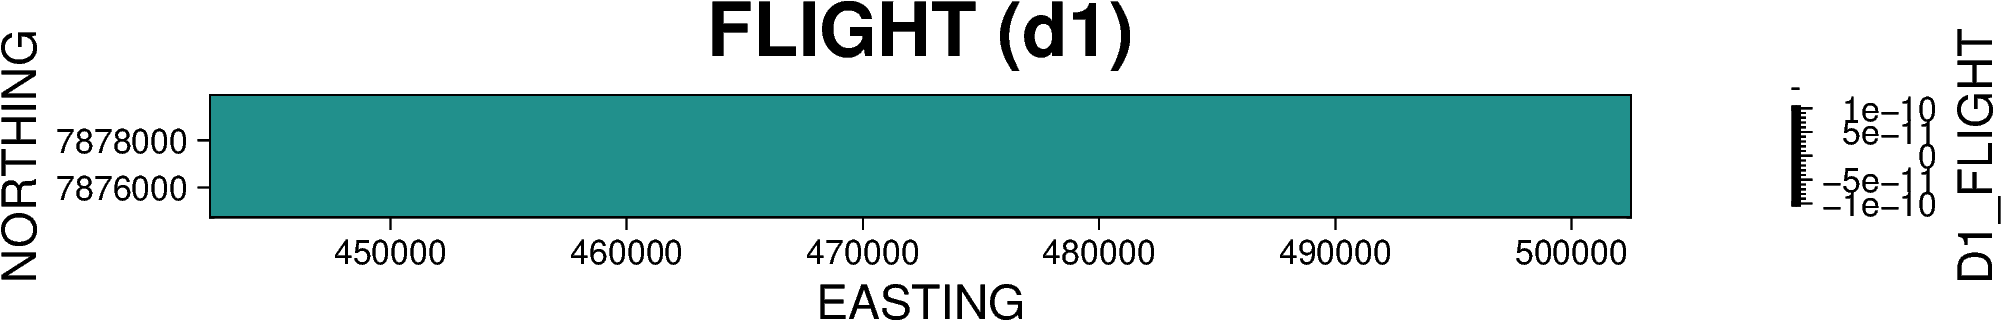

Gridding and imaging GDD_Fourier_2p67
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, GDD_Fourier_2p67). GDD_Fourier_2p67 in eotvos.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (-20.92, 53.42)


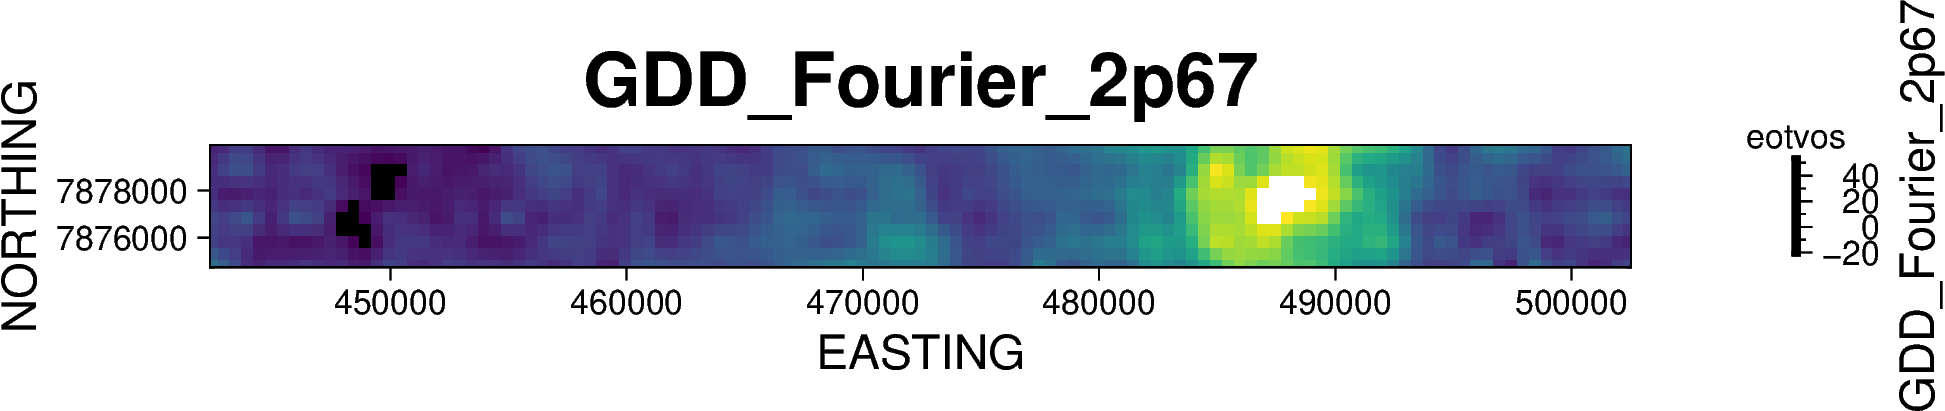

Gridding and imaging NumSats
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, NumSats). NumSats in -.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (8.078, 14.2)


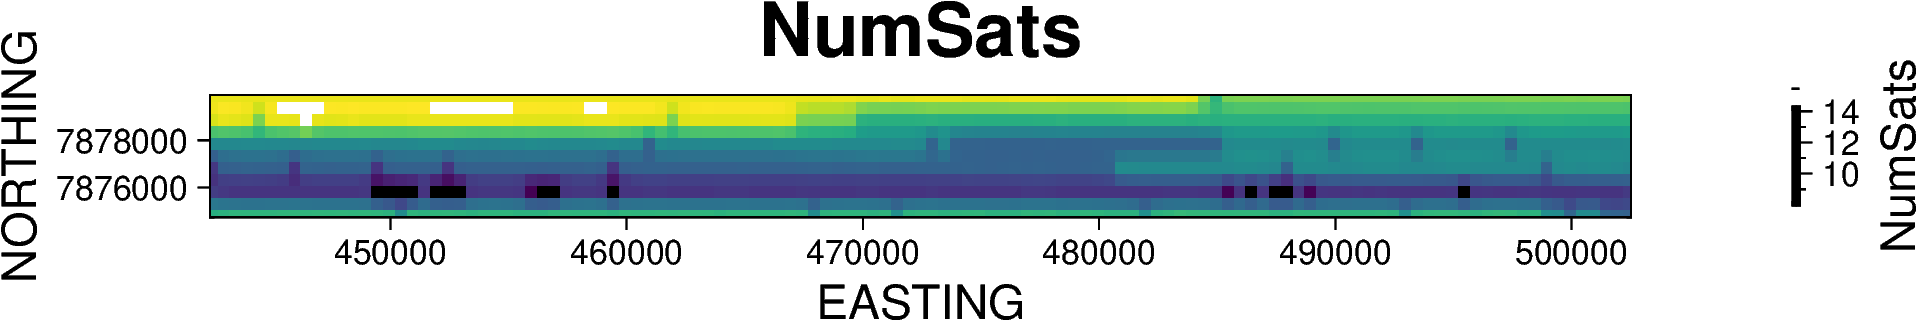

Gridding and imaging T_DD
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, T_DD). T_DD in eotvos.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (-0.7742, 5.812)


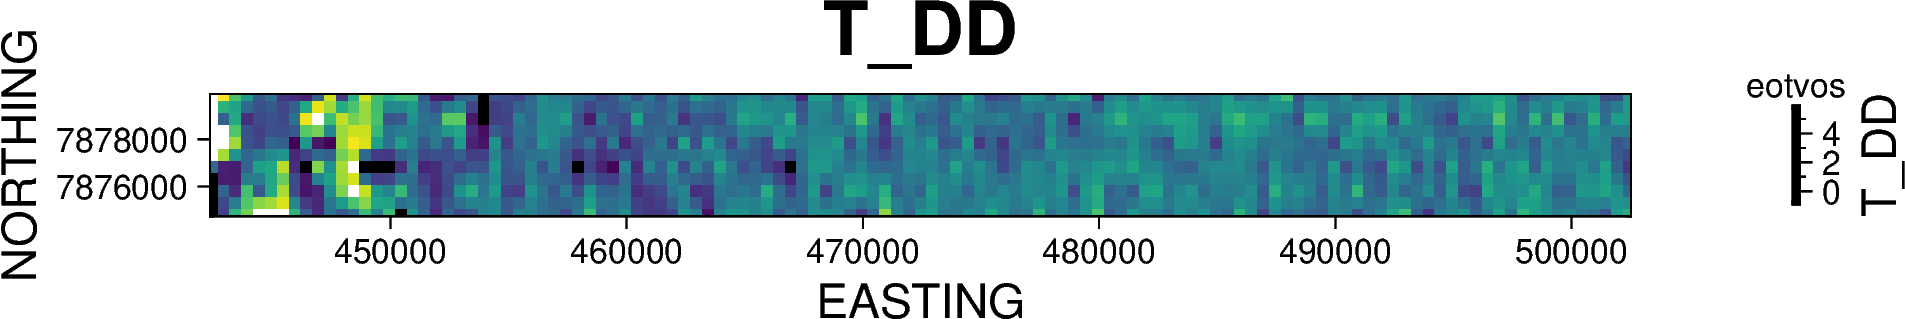

Gridding and imaging Time_1980
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, D1_Time_1980). D1_Time_1980 in seconds.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]


surface [WARNING]: Input data lie exactly on a plane.


z range (1st to 99th percentile) (0.125, 0.125)


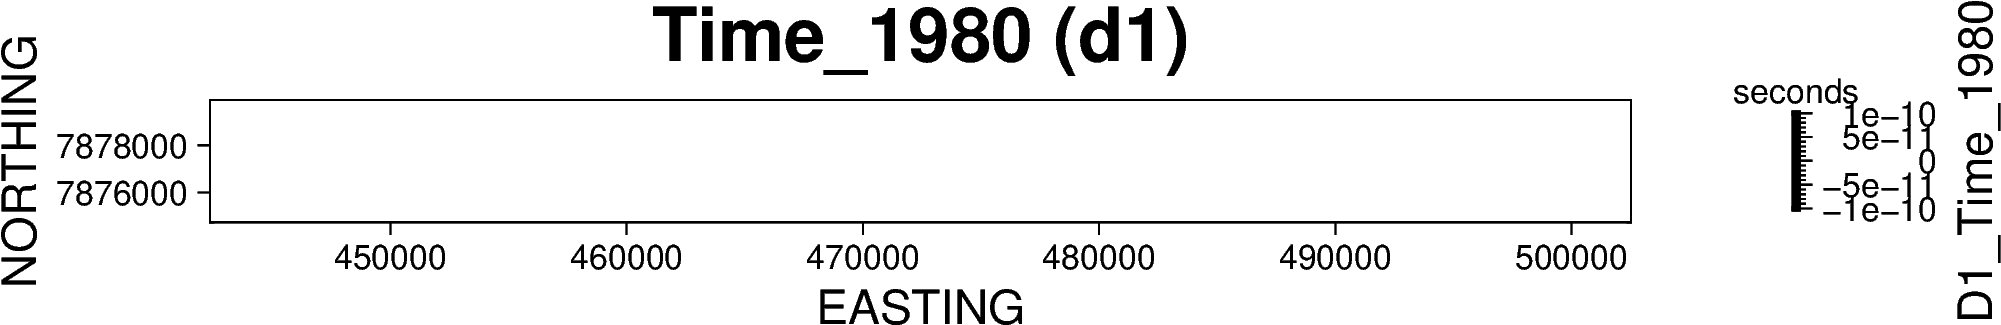

Gridding and imaging gD_Fourier_2p67
Total number of fids in whizz file = 48583.
Processing (x, y, z) = (EASTING, NORTHING, gD_Fourier_2p67). gD_Fourier_2p67 in µm/s/s.
Data points cover region: [ 442443.  502444. 7874812. 7879855.]
z range (1st to 99th percentile) (-10.69, 23.65)


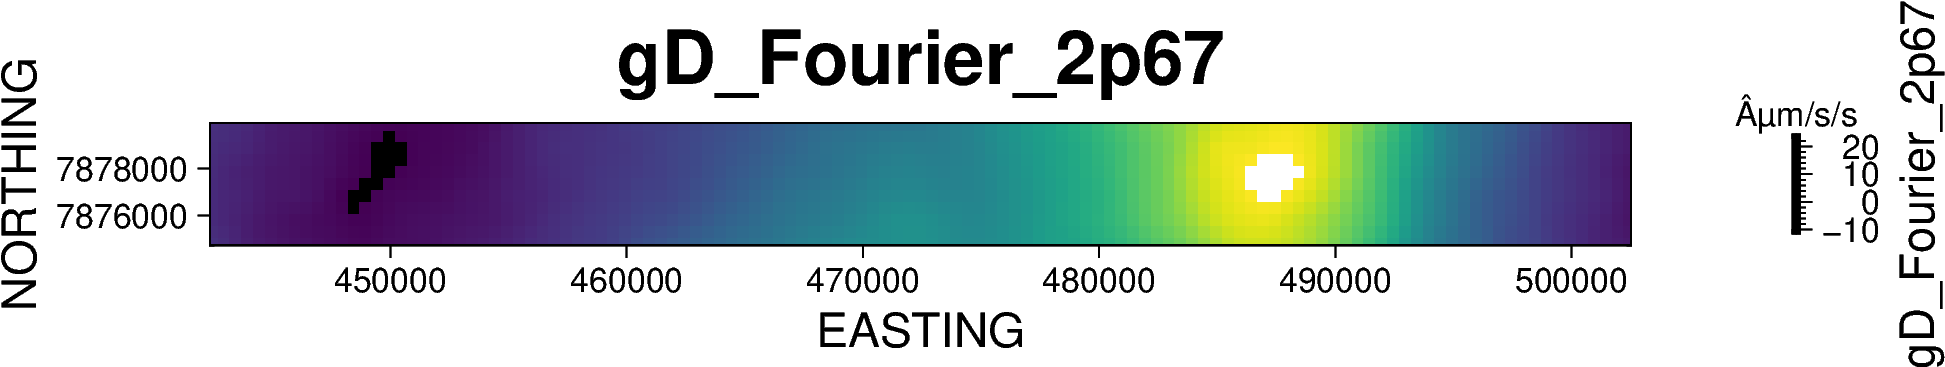

In [92]:
z_chans = ['Bearing', 'CLEARANCE', 'DTM', 'FLIGHT', 'GDD_Fourier_2p67', 'NumSats',
           'T_DD', 'Time_1980', 'gD_Fourier_2p67']
mr_chans = ['Bearing']
d1_chans = ['FLIGHT', 'Time_1980']
grd.grid_n_image(canobieHDF_file, z_chans, mr_chans, d1_chans, 500.0)